## Intro
<p>In this project, I'll predict energy consumption over time using statistical modeling and time series forecasting. I'm going to start by exploring the time series, preparing the data and applying relevant techniques, if necessary, and then I'll proceed to build models to forecast energy consumption over time and its trend.</p>

## Loading and Exploring the data

In [1]:
# 1. Import necessary packages for this project
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as m
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss

In [2]:
# 2. Formatting graph parameters so there's a standard formatting setup for the plots
# Set matplotlib to default style
plt.style.use("default")

# Allow all columns to display without truncation
pd.set_option("display.max_columns", 500)

# Auto-adjust pandas display width for readability
m.rcParams["figure.figsize"] = (12, 6)

# Set font size for axis labels and tick labels
m.rcParams["axes.labelsize"] = 12
m.rcParams["xtick.labelsize"] = 10
m.rcParams["ytick.labelsize"] = 10

# Make axis titles bold for emphasis
m.rcParams["axes.titleweight"] = "bold"

# Ensure text color is black for readability
m.rcParams["text.color"] = "black"

# Increase line width for better readability
m.rcParams["lines.linewidth"] = 2

# Set axis lines: thin, light gray for subtlety
m.rcParams["axes.axisbelow"] = True
m.rcParams["axes.grid"] = False
m.rcParams["axes.linewidth"] = 0.8
m.rcParams["grid.alpha"] = 0.5

In [3]:
# 3. Loading the dataset
df = pd.read_csv(r"C:\Users\paul_\OneDrive\Documentos\Python Scripts\energy_consumption_time_series_forecasting\energy.csv")

# 4. Visualizing the dataset
df.head()

,Time,Value
0,2010-01,62623.196
1,2010-02,55850.217
2,2010-03,57069.645
3,2010-04,51282.697
4,2010-05,54092.590


<p>As we can observe, our time series has two columns, <code>Time</code> which corresponds to the month and <code>Value</code> which corresponds to the energy consumption value. For better readability I'm going to <strong>assign proper column names</strong> so it's easier to understand the values I'm working with.</p>

In [4]:
# 5. Renaming the column names for better readability and understanding
df.columns = ['month', 'energy_consumption']

# 6. Visualizing the data
df.head()

,month,energy_consumption
0,2010-01,62623.196
1,2010-02,55850.217
2,2010-03,57069.645
3,2010-04,51282.697
4,2010-05,54092.590


<p>Now this looks much better.<br> The time series is monthly and it has the energy consumption of each month. I do not know about in what unit of measurement was this measured but, this is not relevant for the purpose of this project. Moving on, I'll show a quick overview of the statistical summary of the time series by using <code>describe()</code>.</p>

In [5]:
# 7. Compute statistical summary of the time series
df.describe()

,energy_consumption
count,157.000000
mean,53956.577204
std,8112.388159
min,33700.149900
25%,48579.754000
50%,54710.420000
75%,58841.769100
max,90804.056000


<p>The <strong>average energy consumption is ~54K.</strong> The <b>minimum</b> consumption has been around 33.7K while the <b>maximum</b> has reached up to 90.8K, quite a significant difference. Next, I'll check what month registered the maximum energy consumption.</p>

In [6]:
# 8. Month with the highest energy consumption
df.max()

month                   2023-01
energy_consumption    90804.056
dtype: object

<p>Now I'm going to verify the <strong>time series range</strong> by identifying the minimum and maximum dates in the data.</p>

In [7]:
# 9. Indetifying the full period of the energy consumption record
print("Start of Time Period: {}\nEnd of Time Period: {}".format(
    df.month.min(), df.month.max()
))

Start of Time Period: 2010-01
End of Time Period: 2023-01


<p>So the data was taken from <strong>January, 2010</strong> until <strong>January, 2023.</strong> The time series contains the energy consumption of 13 years. Let's check the shape and the type of the time series now.</p>

In [8]:
# 10. Shape of the time series
df.shape

(157, 2)

In [9]:
# 11. Type of the time series
type(df)

pandas.core.frame.DataFrame

<p>The time series has 157 rows and 2 columns. Its type is <strong>Pandas DataFrame</strong> which is the ideal structure we should be working with for data manipulation and time series analysis in Python. Now we can go to the next step which is to set the datetime column as the index</p>

## Data Preprocessing and Visualization

<p>I'll start with some initial data processing and then, move on to visualization to understand the time series behavior better</p>

In [10]:
# 12. Viewing the data
df.head()

,month,energy_consumption
0,2010-01,62623.196
1,2010-02,55850.217
2,2010-03,57069.645
3,2010-04,51282.697
4,2010-05,54092.590


In [11]:
# 13. Check the data types
df.dtypes

month                  object
energy_consumption    float64
dtype: object

<p>The <code>energy_consumption</code> column is a <b>float64</b> while the <code>month</code> columns is an <b>object</b> which is a string in Python. While the energy_consumption type is fine, that's not the case for <code>month</code>, this column represents a date and keeping it as string can limit us to apply techniques and can make it hander for us to manipulate the data so I'll proceed to convert the <code>month</code> column to <b>pandas datetime</b> type.</p>

In [12]:
# 14. Convert 'month' column to pandas datetime type
df["month"] = pd.to_datetime(df["month"], format='%Y-%m')

# 15. Viewing the data
df.head()

,month,energy_consumption
0,2010-01-01,62623.196
1,2010-02-01,55850.217
2,2010-03-01,57069.645
3,2010-04-01,51282.697
4,2010-05-01,54092.590


<p>Now that I have fixed the problem with the <code>month</code> column, I'll go ahead and set it as the <b>DataFrame Index</b> to ensure proper time series analysis. Once I've done this, our time series data will be ready to start with the proper analysis.</p>

In [13]:
# 16. Setting 'month' column as the DataFrame Index
df_series = df.set_index('month')

# 17. Viewing the data
df_series.head()

,energy_consumption
month,
2010-01-01,62623.196
2010-02-01,55850.217
2010-03-01,57069.645
2010-04-01,51282.697
2010-05-01,54092.590


<p>Let's <strong>see our time series Index.</strong></p>

In [14]:
# 18. Visualizing the index
df_series.index

DatetimeIndex(['2010-01-01', '2010-02-01', '2010-03-01', '2010-04-01',
               '2010-05-01', '2010-06-01', '2010-07-01', '2010-08-01',
               '2010-09-01', '2010-10-01',
               ...
               '2022-04-01', '2022-05-01', '2022-06-01', '2022-07-01',
               '2022-08-01', '2022-09-01', '2022-10-01', '2022-11-01',
               '2022-12-01', '2023-01-01'],
              dtype='datetime64[ns]', name='month', length=157, freq=None)

<p>Currently, each date is an index with its corresponding energy consumption value. Next, let's check for <b>missing values.</b></p>

In [15]:
# 19. Verifying for any missing values
df_series.isna().sum()

energy_consumption    0
dtype: int64

<p>Our time series has <strong>no missing values</strong> which is good and allows to proceed further. Let's move on to <b>statistical modeling</b>.</p>

## Time Series Trend Analysis

<p>Let's now visualize our time series to analyze it and understand it by calling <code>.plot()</code> method.</p>

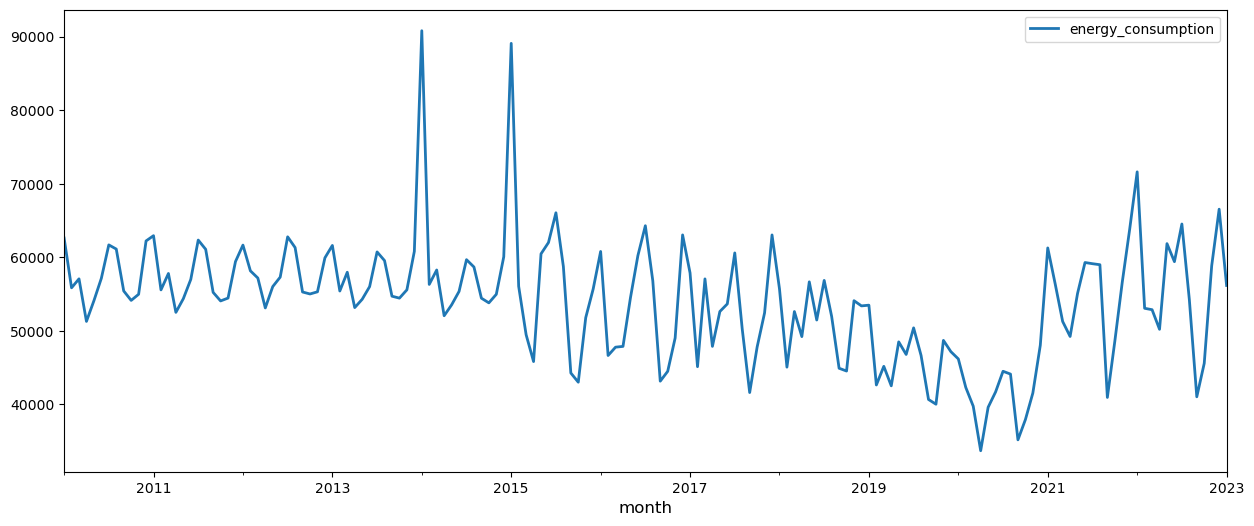

In [16]:
# 20. Graph the time series to observe the trend
df_series.plot(figsize=(15, 6))
plt.show()

<p>In the graph we can observe that the time series has a <strong>downwards trend</strong> or <strong>negative trend</strong> until 2021 that is when it turns to an <strong>upwards trend</strong>. We can also observe cycles of highs and lows, this could be linked to seasonal variations.</p>

## Time Series Density Plot

<p>Next, I'm going to create a second plot using a <em><strong>density plot</em></strong>. Create two graphs:<br><ul><li>A <b>histogram plot</b> to show the distribution of the numerical values in the time series</li><li>A <b>KDE (Kernel Density Estimation) plot</b>, representing the actual density curve</li></ul></p>

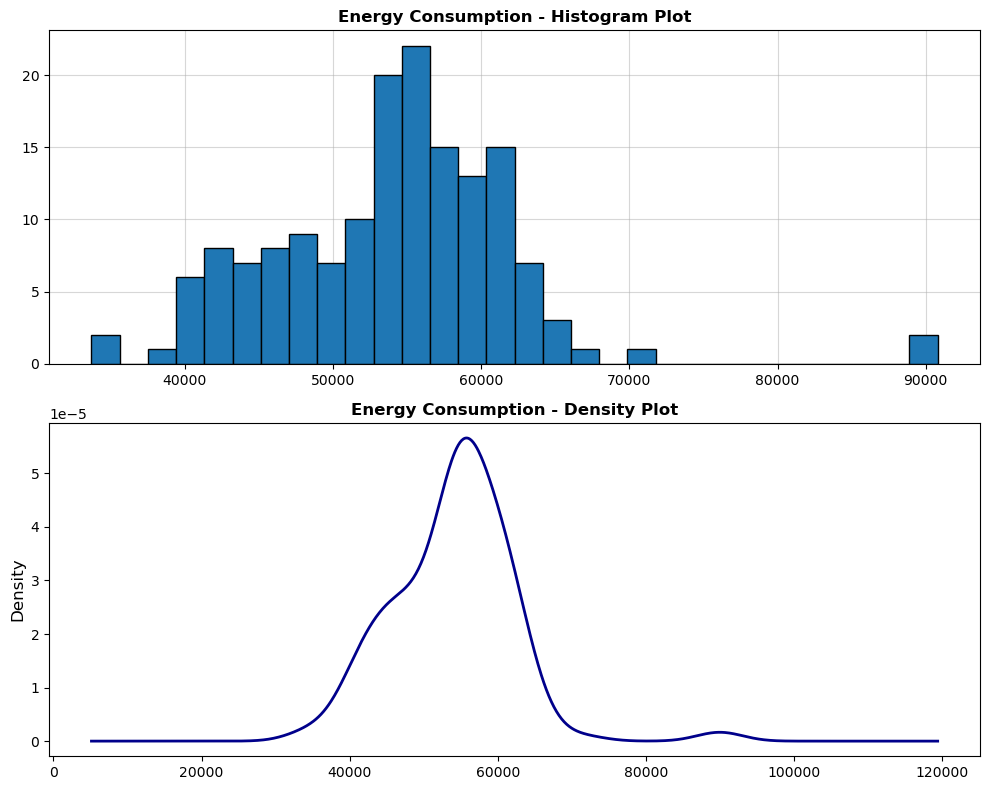

In [17]:
# 21.a Create the fisgure to show both graphs in one image
plt.figure(figsize=(10, 8))

# 21.b Create a histogram to show the distribution of the taxi orders
plt.subplot(2, 1, 1)
df_series['energy_consumption'].hist(
    bins=30, edgecolor='black'
)
plt.title('Energy Consumption - Histogram Plot')

# 21.c KDE plot to analyze the distribution shape
plt.subplot(2, 1, 2)
df_series['energy_consumption'].plot(
    kind='kde', linewidth=2, color='darkblue'
)
plt.title('Energy Consumption - Density Plot')

plt.tight_layout()
plt.show()

<p>As observed in the figure, our time series shows a similar <strong>Gaussian distribution</strong>, even thoug not perfect, it shows a negative skew (left skew). This might indicate that transformations could help in modeling, as many models assume normality. This transformations could improve the distribution to make it more of a theorical normal distribution which could improve our model performance.<br>It does not show abnormalities, it has a lump of data at the end and a long tail at the beggining.</p>

## Visualizing Time Series Decomposition

<p>Now let's decompose our time series to analyze each component separately.<br>I'm going to apply the two main decomposition types:<ul><li><strong>Additive</strong>: The components are summed</li><li><strong>Multiplicative</strong>: The components are multiplied</li></ul>After applying both decompositions I'll compare the results and decide which one to use. Let's begin with <b>multiplicative decomposition</b>.</p>

In [18]:
# 22. Performing multiplicative decomposition to the time series
decomposition_multiplicative = seasonal_decompose(
    df_series, model='multiplicative', extrapolate_trend='freq', period=12
)

Text(0.5, 0.98, 'Multiplicative Decomposition')

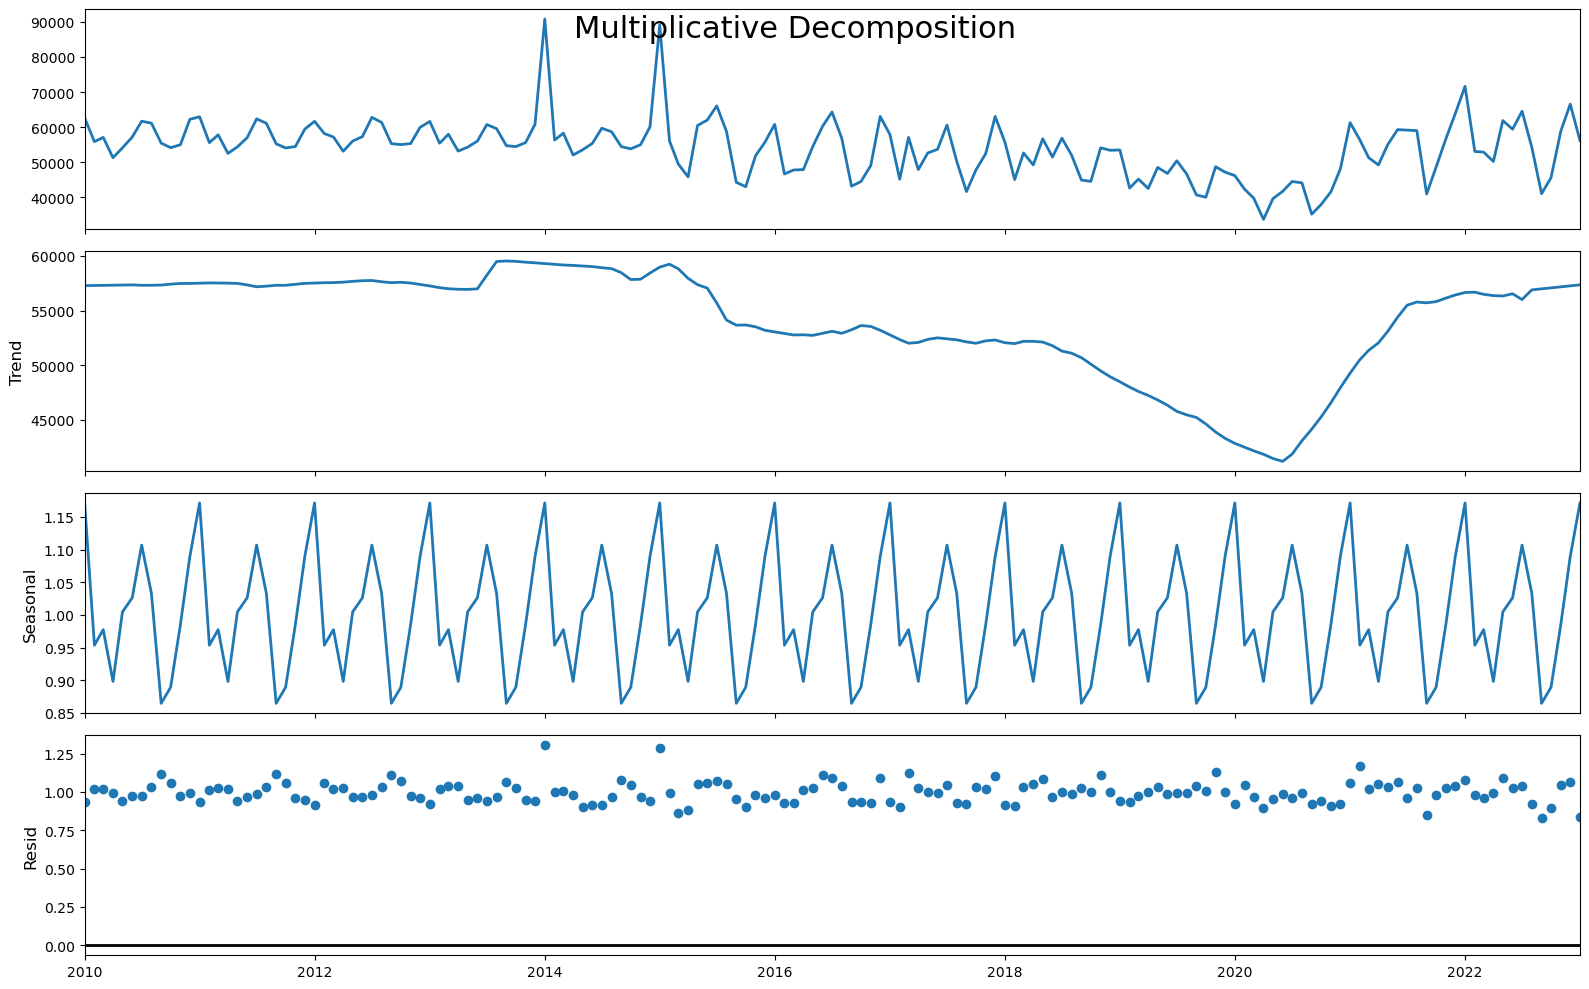

In [19]:
# 23.a Configure plot size
plt.rcParams.update({'figure.figsize': (16, 10)})

# 23.b Plot the multiplicative decomposition
decomposition_multiplicative.plot().suptitle('Multiplicative Decomposition', fontsize=22)

<p>Next I'll check and plot the <b>Additive Decomposition</b> to compare both and finally decide which one decompose my time series in a better way.</p>

Text(0.5, 0.98, 'Additive Decomposition')

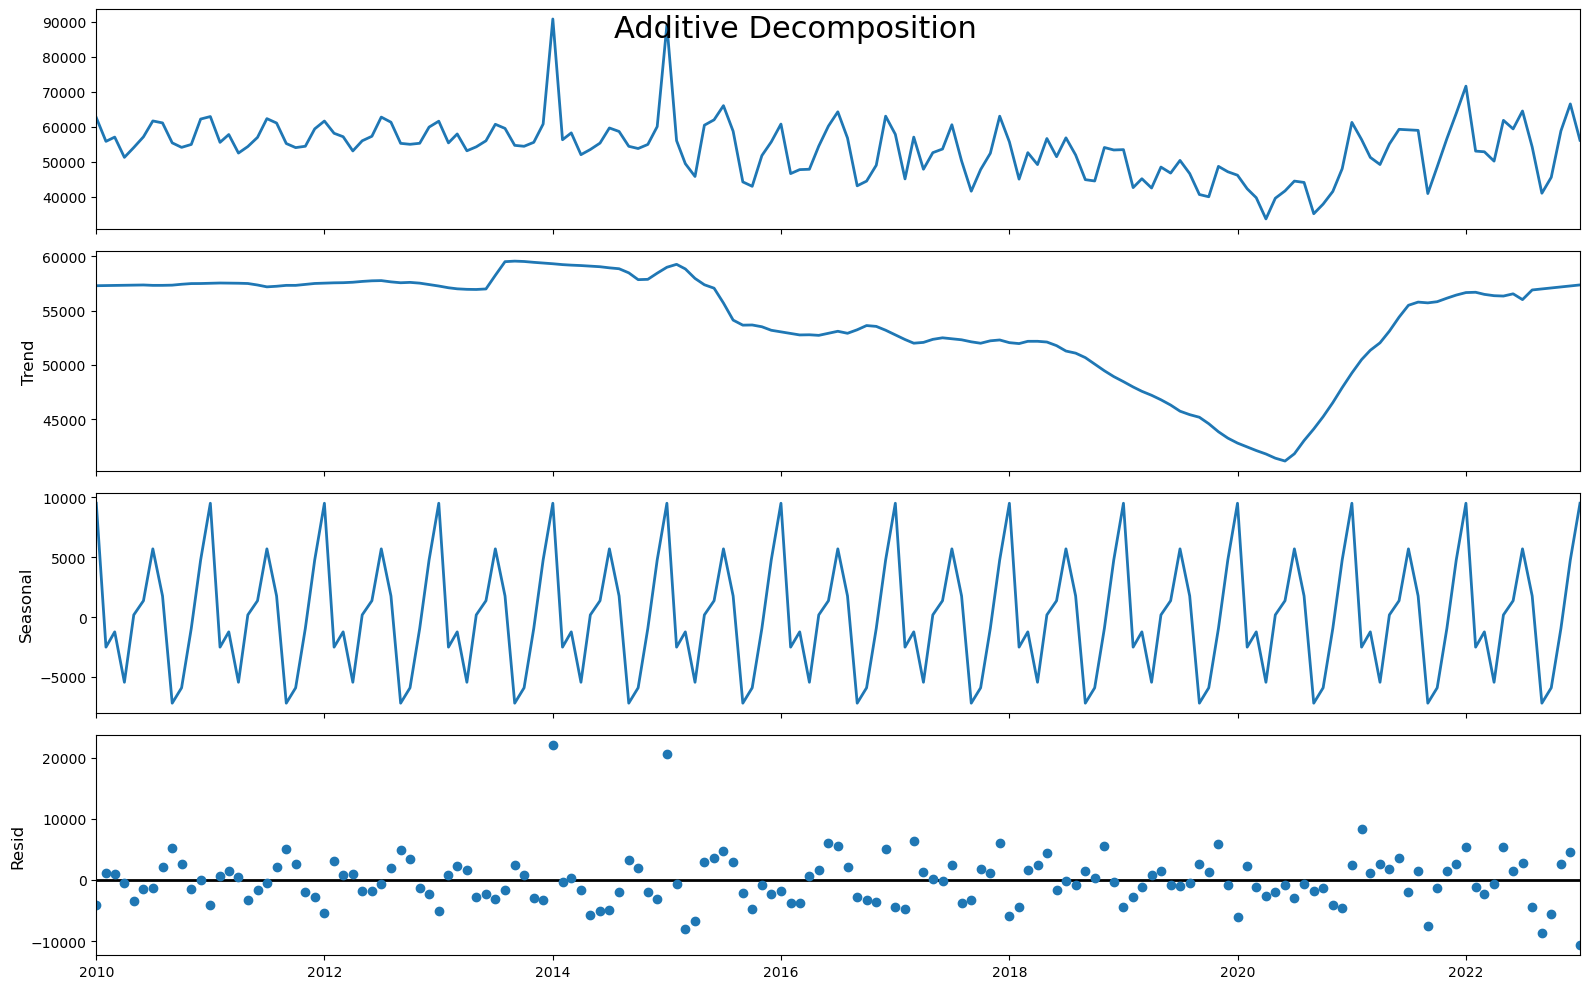

In [20]:
# 24. Performing additive decomposition to the time series
decomposition_additive = seasonal_decompose(
    df_series, model='additive', extrapolate_trend='freq', period=12
)

# 25.a Configure plot size
plt.rcParams.update({'figure.figsize': (16, 10)})

# 25.b Plot the additive decomposition
decomposition_additive.plot().suptitle('Additive Decomposition', fontsize=22)

<p>The key to know which decomposition method is better, is in the <strong>residual graph</strong>, it doesn't have to follow a clear pattern as it indicates that the underlying trend and seasonal components have not successfully captured all of the systematic information in the time series data. Instead of being white noise (random fluctuation), the residuals still contain structural information, such as a missed cycle, a sudden break, or a shifting trend. So, next I'll try another method, <b>STL</b> and see if this method can decompose our time series in a better way.</p>

Text(0.5, 0.98, 'STL Decomposition')

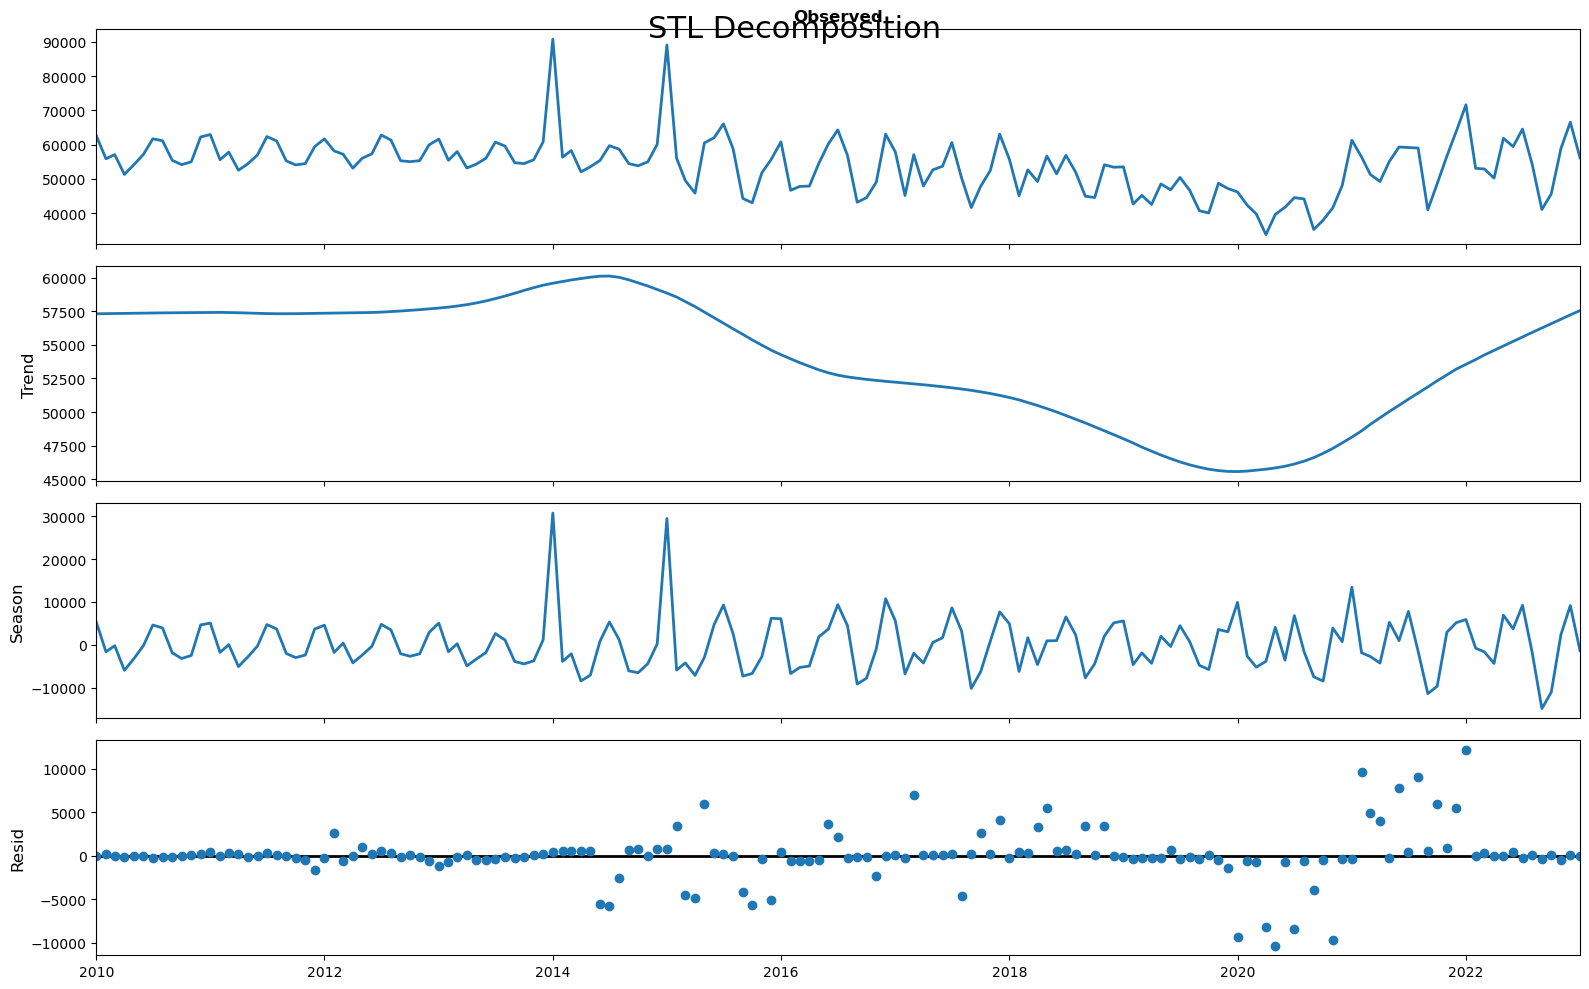

In [21]:
# 26. Instead of: sm.tsa.seasonal_decompose(data...)
# Use STL:
stl = STL(df_series, period=12, seasonal=5, robust=True)
result = stl.fit()

# 27.a Configure plot size
plt.rcParams.update({'figure.figsize': (16, 10)})

# 27.b Plot the STL decomposition
result.plot().suptitle('STL Decomposition', fontsize=22)

<p>This last method, <b>STL</b> performs better than <strong> Additive/Multiplicative</strong>. I'll use it to move forward in the analysis. Next, let's extract the components of the time series and validate the decomposition.</p>

In [22]:
# 28. Concatenate the decomposed components of the time series
df_series_reconstructed = pd.concat(
    [
        result.seasonal, # Seasonal component
        result.trend, # Trend component
        result.resid, # Residual component
        result.observed # Original time series
    ], axis = 1
)

# 28.a Rename the columns for better readability
df_series_reconstructed.columns = ['Seasonality', 'Trend', 'Residuals', 'Observed_Values']

# 29. Viewing the DataFrame
df_series_reconstructed.head()

,Seasonality,Trend,Residuals,Observed_Values
month,,,,
2010-01-01,5329.218024,57309.395798,-15.417822,62623.196
2010-02-01,-1660.735829,57320.393311,190.559517,55850.217
2010-03-01,-233.384522,57331.259361,-28.229839,57069.645
2010-04-01,-5980.069629,57341.860766,-79.094138,51282.697
2010-05-01,-3295.203054,57352.041019,35.752036,54092.590


## Assumptions for Time Series Statistical Modeling

<p>Before performing any modeling, we must validate if the time series meets few key statistical assumptions. If it doesn't it can lead to wrong results. In the case that the time series doesn't meet the criteria we can apply transformations to meet the key assumptions.<br>We should ensure these properties remain constant:<ol><li><strong>Stationarity:</strong> this means that the mean and variance do not change over time.</li><li><strong>No autocorrelation:</strong> the observations must not be strongly correlated with previous values</li><li><strong>Normal distribution:</strong> There are many models that assume that the time series follows a normal distribution.</li></ol>We must validate this assumptions one by one, if the time series fails in one of them we must fix it before checking the next one. Sometimes fixing one will automatically fix another one.</p>

## Rolling Statistics Plot (Moving Averages)

<p>One way to validate stationarity is by plotting <strong>rolling statistics</strong>. If it fails to pass then there's an issue and we might need to do some data transformation in order to fix it.</p>

In [23]:
# 30. Compute rolling statistics for trend analysis
# 30.a Calculate the 12month moving average
rolling_mean = df_series['energy_consumption'].rolling(12).mean()

# 30.b Calculate the 12month moving standard deviation
rolling_std = df_series['energy_consumption'].rolling(12).std()

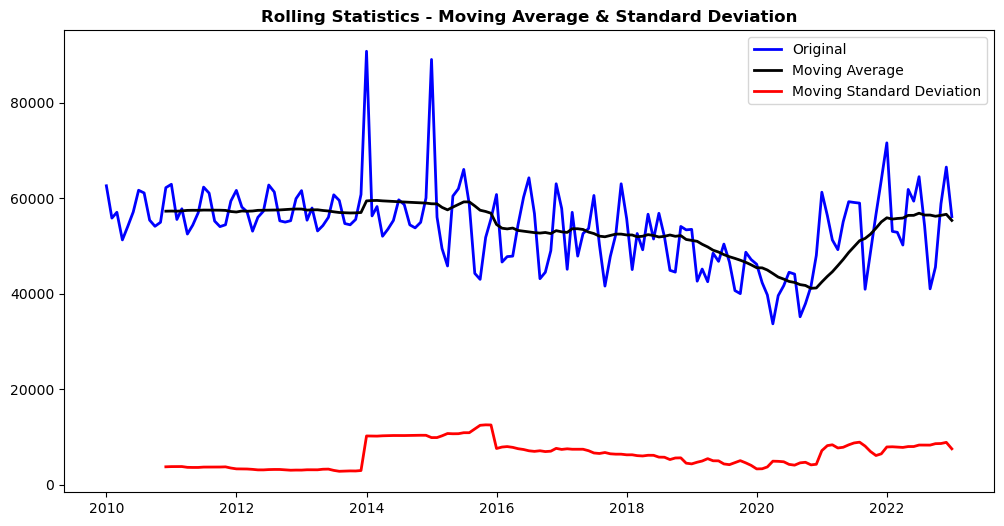

In [24]:
# 31. Plot rolling statistics for trend and variance analysis
plt.figure(figsize=(12, 6))

# 31.a Plot the original time series values
plt.plot(df_series['energy_consumption'], color='blue', label='Original')

# 31.b Plot moving average (rolling mean)
plt.plot(rolling_mean, color='black', label='Moving Average')

# 31.c Plot moving standard deviation
plt.plot(rolling_std, color='red', label='Moving Standard Deviation')

# 31.d Configure legend and title
plt.legend(loc='best')
plt.title('Rolling Statistics - Moving Average & Standard Deviation')
plt.show()

<p>In this graph, shows that both, the moving average and std deviation fluctuate over time, confirming that the time series is <strong>non-stationary</strong>; however, we'll do some statistical tests to confirm that so we don't have to depend on the eye. If the tests confirm a <strong>non-stationary time series</strong> it would be violating the first key assumption and we would need to fix that.</p>

## Autocorrelation and Partial Autocorrelation plots

<p>Next, I need to verify the second key assumption, that the time series lacks of autocorrelation. To validate, I'll use:<ul><li><strong>ACF (Autocorrelation Function)</strong> plot</li><li><strong>PACF (Partial Autocorrelation Function)</strong> plot</li></ul></p>

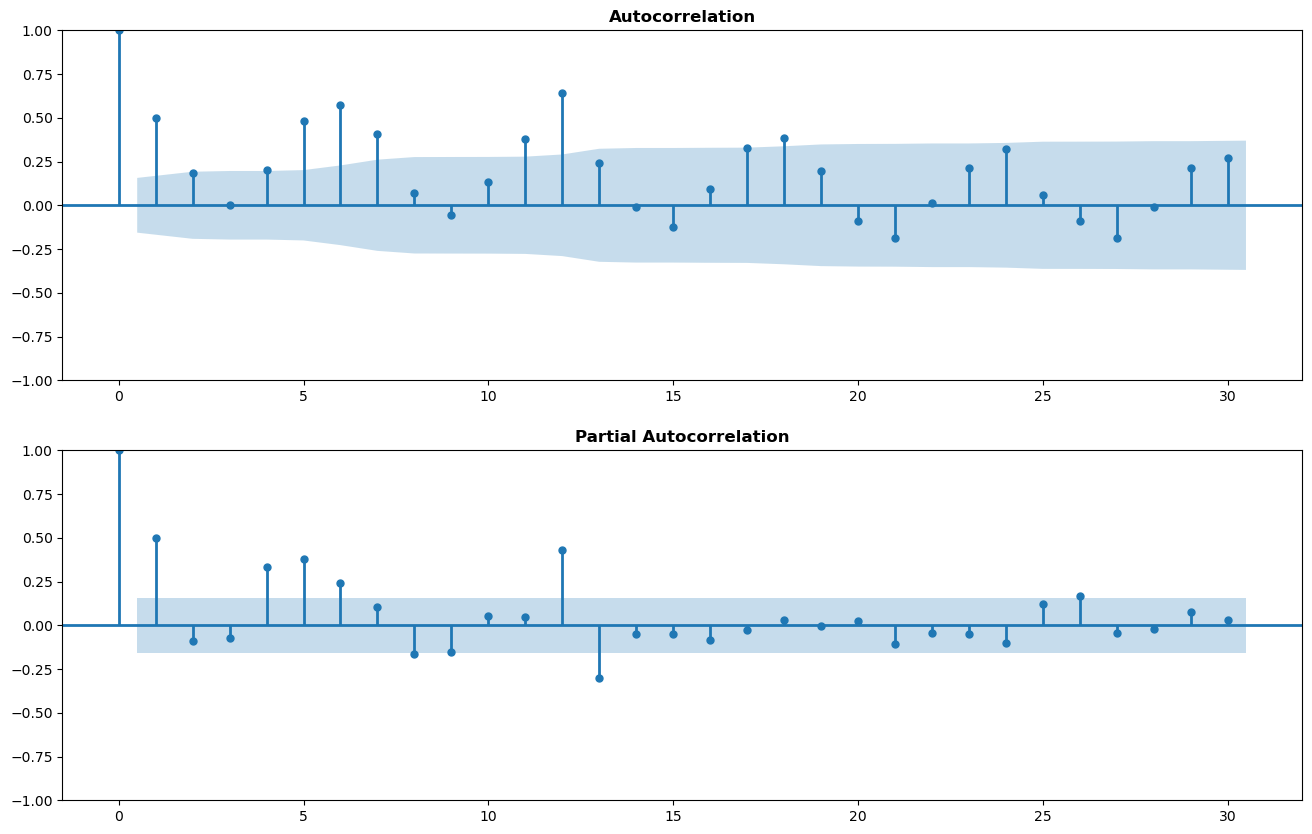

In [25]:
# 32. Set global figure size for visualization
plt.rcParams.update({'figure.figsize': (16, 10)})

# 33 Plot the ACF (Autocorrelation function) plot

# 33.a Define subplot for ACF plot
plt.subplot(2, 1, 1)

# 33.b Generate ACF plot with 30 lags
plot_acf(df_series['energy_consumption'],
        ax=plt.gca(), lags=30)

# 34. Plot the PACF (Partial Autocorrelation Function) plot

# 34.a Define the subplot for PACF plot
plt.subplot(2, 1, 2)

# 34.b Generate PACF plot with 30 lags
plot_pacf(df_series['energy_consumption'],
        ax=plt.gca(), lags=30, method='ywm')

plt.show()

<p>All points, blue dots, must fall under the shaded blue area indicating that there is no significant autocorrelation; however, this is not the case. Both graphs show that there are some blue dots that fall outside, which corroborates that <strong>autocorrelation exists</strong>.<br>I'm going to fix the <strong> non-stationary</strong> issue first. Sometimes, fixing one issue can solve another one so, let's fix <b>stationary issue</b> and then validate if the autocorrelation still exists.</p>

## Augmented Dickey-Fuller (ADF) Test

<p>The <strong>ADF (Augmented Dickey-Fuller) test</strong> is a <strong>hypothesis test</strong> to check whether a time series is stationary or not.<br>The test evaluates two hypothesis:<ul><li><strong>Null Hypothesis (H<sub>0</sub>):</strong> The time series is <strong>non-stationary.</strong></li><li><strong>Alternative Hypothesis (H<sub>1</sub>):</strong> The time series <strong>is stationary.</strong></li></ul><strong>Decision Rule:</strong><ul><li>If the <strong> p-value <0.05,</strong> we <strong>reject H<sub>0</sub>,</strong> meaning the series <strong>is stationary.</strong></li><li>If the <strong> p-value &ge;0.05,</strong> we <strong>fail to reject H<sub>0</sub>,</strong> meaning the series is <strong>non-stationary.</strong></li></p>

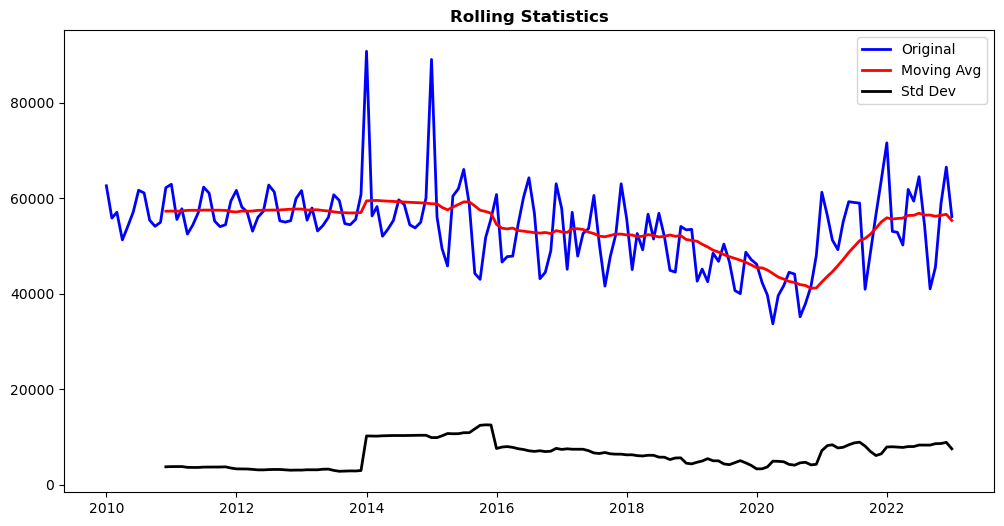


Dickey-Fuller Test Results:

Test Statistic           -1.678125
p-value                   0.442417
Lags Used                12.000000
Observations Used       144.000000
Critical Value (1%)      -3.476598
Critical Value (5%)      -2.881829
Critical Value (10%)     -2.577589
dtype: float64

The series is non-stationary (p >= 0.05).


In [26]:
# 35. Function to test stationarity in time series
def adf_test_stationarity(series):
    
    # 35.a Compute rolling statistics
    rolling_mean = series.rolling(12).mean()
    rolling_std = series.rolling(12).std()
    
    # 35.b Plot rolling statistics
    plt.figure(figsize=(12, 6))
    plt.plot(series, color='blue', label='Original')
    plt.plot(rolling_mean, color='red', label='Moving Avg')
    plt.plot(rolling_std, color='black', label='Std Dev')
    plt.legend(loc='best')
    plt.title('Rolling Statistics')
    plt.show()
    
    # 35.c Perform the Dickey-Fuller test
    print("\nDickey-Fuller Test Results:\n")
    adf_test = adfuller(series, autolag='AIC')
    
    # 35.d Format the test output
    df_output = pd.Series(adf_test[0:4], index=[
        'Test Statistic', 'p-value', 
        'Lags Used', 'Observations Used'])
    
    # 35.e Append critical values
    for key, value in adf_test[4].items():
        df_output[f'Critical Value ({key})'] = value
    
    # 35.f Display results
    print(df_output)
    
    # 35.g Interpret stationarity based on p-value
    p_value = adf_test[1]
    if p_value < 0.05:
        print("\nThe series is stationary (p < 0.05).")
    else:
        print("\nThe series is non-stationary (p >= 0.05).")

# 36. Execute the stationarity test function
adf_test_stationarity(df_series)

<p>The <b>p-value</b> is greater than 0.05, hence there is no evidence to reject the null hypothesis, suggesting that the time series is non-stationary. This provides a more solid prove to confirm with no doubt that the time series is <strong>non-stationary</strong> and since this violates the <strong>first key statistical assumption</strong> we must apply transformations before moving on to modeling.</p>

##  Kwiatkowski–Phillips–Schmidt–Shin (KPSS) Test

<p>The <strong>KPSS (Kwiatkowski–Phillips–Schmidt–Shin) test</strong> is, as ADF test, a <strong>statistical test</strong> to determine if a data series is stationary or not around a mean or a linear trend (null hypothesis).<br>The test evaluates two hypothesis:<ul><li><strong>Null Hypothesis (H<sub>0</sub>):</strong> The time series is <strong>stationary.</strong></li><li><strong>Alternative Hypothesis (H<sub>1</sub>):</strong> The time series <strong>is non-stationary.</strong></li></ul><strong>Decision Rule:</strong><ul><li>If the <strong> p-value <0.05,</strong> we <strong>reject H<sub>0</sub>,</strong> meaning the series <strong>is non-stationary.</strong></li><li>If the <strong> p-value &ge;0.05,</strong> we <strong> fail to reject H<sub>0</sub>,</strong> meaning the series is <strong>stationary.</strong></li></p>

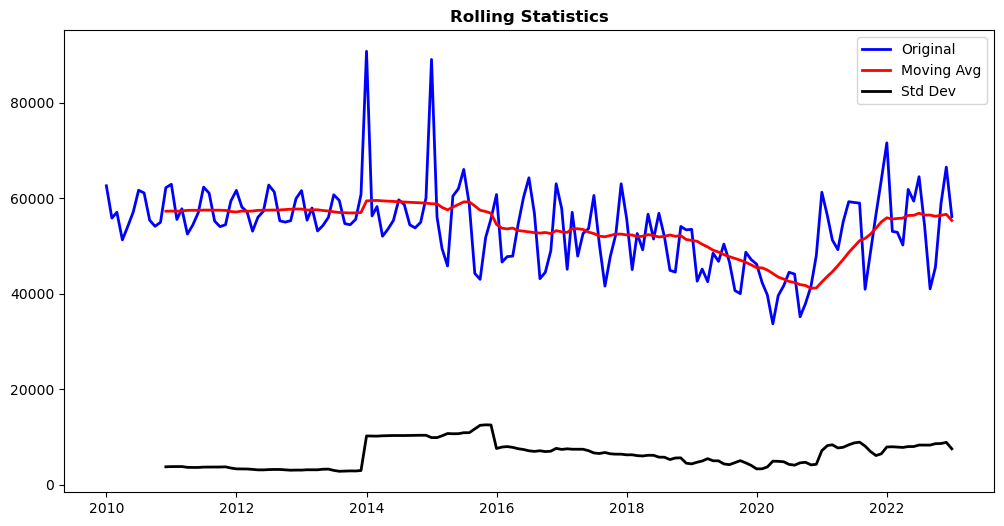


KPSS Test Results:

Test Statistic           1.076068
p-value                  0.010000
Lags Used                5.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64

The series is non-stationary (p < 0.05).


In [27]:
# 37. Silence warnings
import warnings
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter('ignore', InterpolationWarning)

# 38. Function to test stationarity in time series
def kpss_test_stationarity(series):
    
    # 38.a Compute rolling statistics
    rolling_mean = series.rolling(12).mean()
    rolling_std = series.rolling(12).std()
    
    # 38.b Plot rolling statistics
    plt.figure(figsize=(12, 6))
    plt.plot(series, color='blue', label='Original')
    plt.plot(rolling_mean, color='red', label='Moving Avg')
    plt.plot(rolling_std, color='black', label='Std Dev')
    plt.legend(loc='best')
    plt.title('Rolling Statistics')
    plt.show()
    
    # 38.c Perform the Dickey-Fuller test
    print("\nKPSS Test Results:\n")
    kpss_test = kpss(series, regression='c', nlags="auto")
    
    # 38.d Format the test output
    df_output = pd.Series(kpss_test[0:3], index=[
        'Test Statistic', 'p-value', 'Lags Used'])
    
    # 38.e Append critical values
    for key, value in kpss_test[3].items():
        df_output[f'Critical Value ({key})'] = value
    
    # 38.f Display results
    print(df_output)
    
    # 38.g Interpret stationarity based on p-value
    p_value = kpss_test[1]
    if p_value < 0.05:
        print("\nThe series is non-stationary (p < 0.05).")
    else:
        print("\nThe series is stationary (p >= 0.05).")

# 39. Execute the stationarity test function
kpss_test_stationarity(df_series)

<p>The <strong>p-value</strong> is 0.01, smaller than 0.05, which makes us reject the <strong>null hypothesis (H<sub>0</sub>)</strong> suggesting that the data series is very likely <strong>non-stationary</strong>. With both statistical tests indicating the same, we now need to apply techniques to transform our time series to a stationary series.</p>

## Transforming Non-Stationary Time Series

### Log transformation

<p>The first approach is <strong>Log Transformation</strong>. This technique simply <strong>applies logarithms</strong> to the data; in other words, is a simple numerical convertion that rescales the values <strong>without loosing information</strong>. Let's see if this technique is enough to convert our data series into a stationary one. I'll use <code>np.log()</code> to perform the transformation.</p>

In [28]:
# 40. Apply log transformation to stabilize variance
df_series['energy_consumption_log'] = np.log(
    df_series['energy_consumption']
)

# 41. Display the first rows of the transformed dataset
df_series.head()

,energy_consumption,energy_consumption_log
month,,
2010-01-01,62623.196,11.044891
2010-02-01,55850.217,10.930429
2010-03-01,57069.645,10.952028
2010-04-01,51282.697,10.845109
2010-05-01,54092.590,10.898452


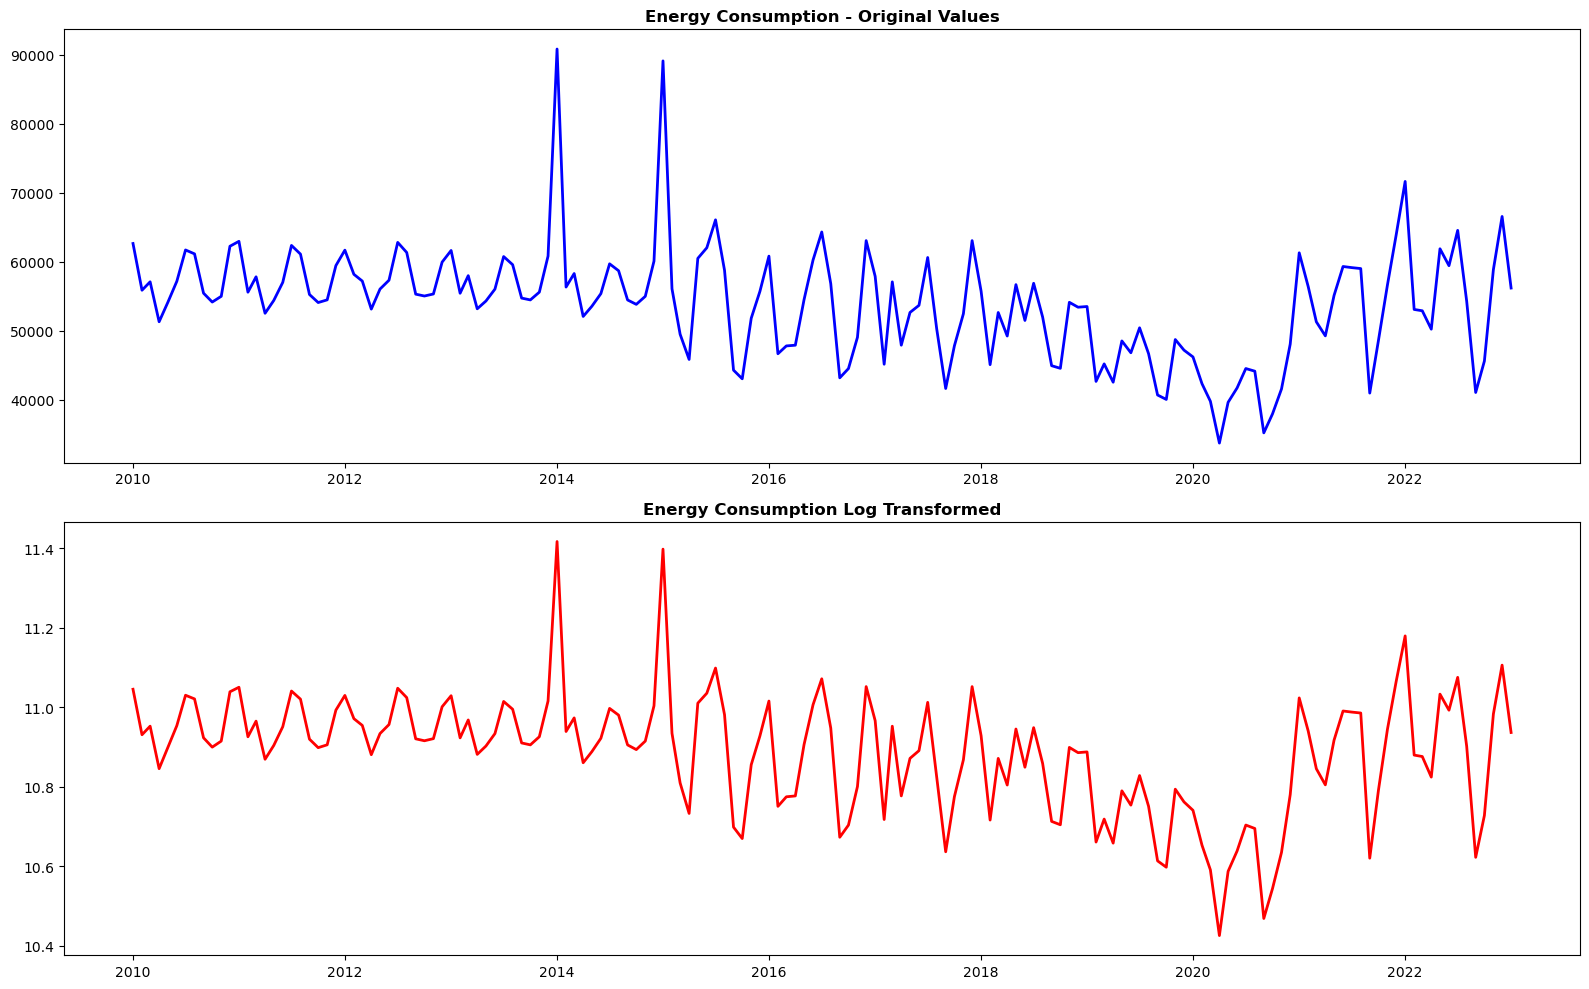

In [29]:
# 42. Plot the log transformation values along with the original values

# 42.a Define a subplot
plt.subplot(2, 1, 1)

# 42.b Plot the original values
plt.plot(df_series['energy_consumption'], color='blue')
plt.title('Energy Consumption - Original Values')

# 42.c Plot the log transformation values
plt.subplot(2, 1, 2)
plt.plot(df_series['energy_consumption_log'], color='red')
plt.title('Energy Consumption Log Transformed')

plt.tight_layout()
plt.show()

<p>There is no significant difference after applying the <strong>Log Transformation technique</strong>. Let's see if any changes in the histogram.</p>

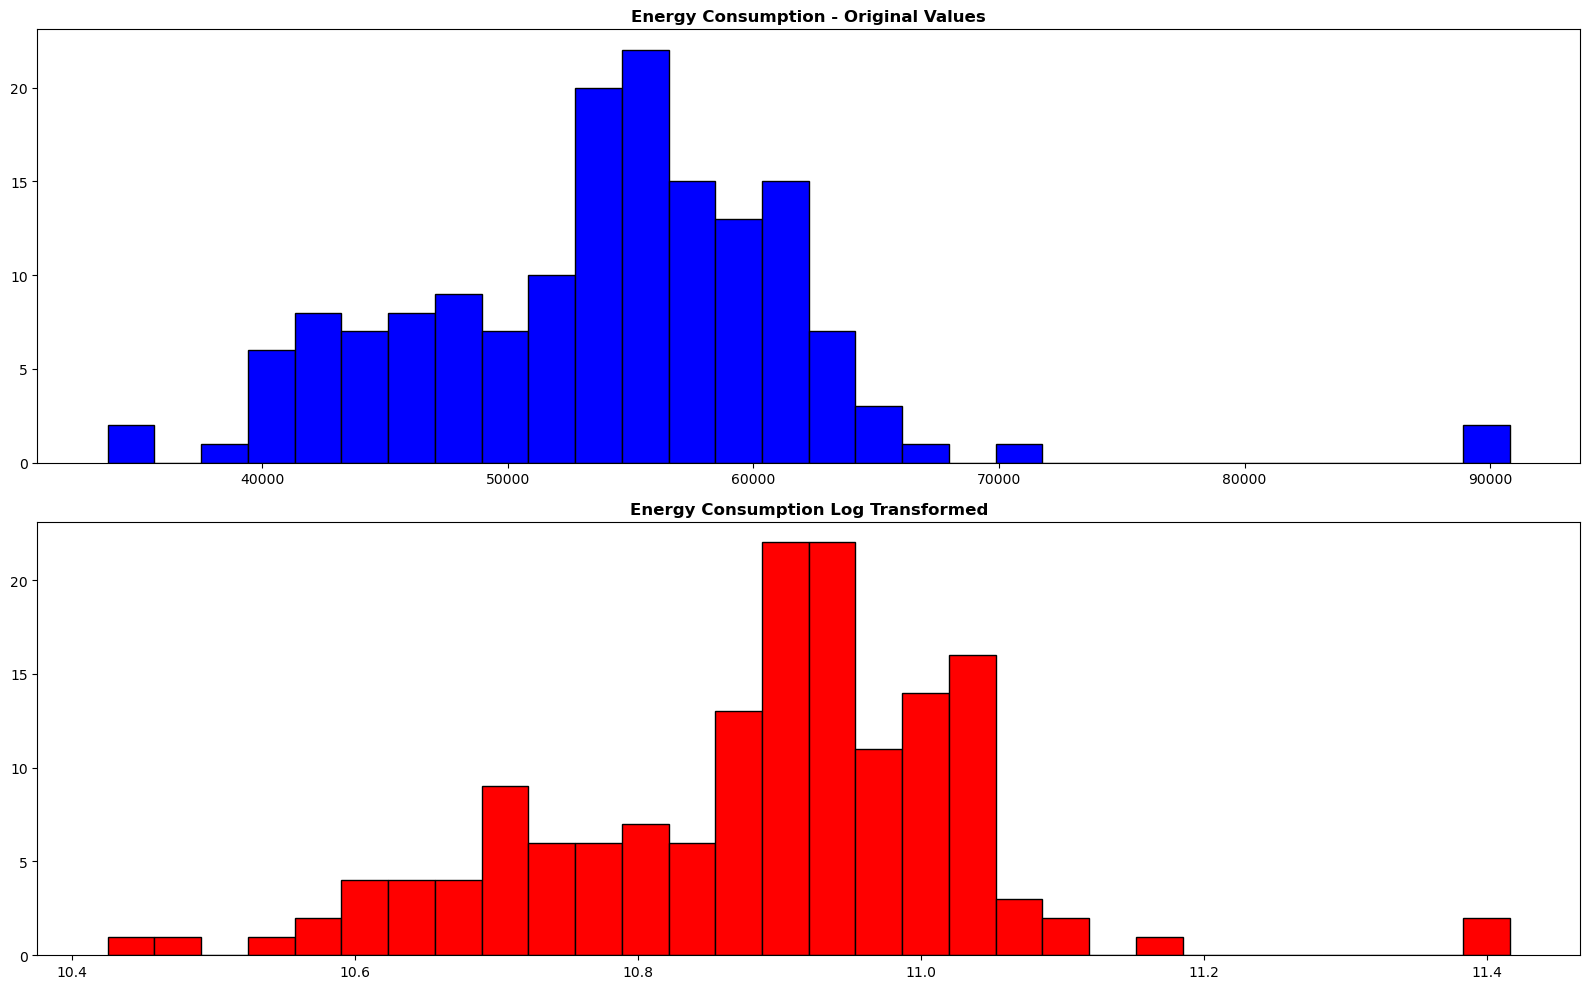

In [30]:
# 43. Plot the histogram of the transformed time series
# 43.a Define a subplot
plt.subplot(2, 1, 1)

# 43.b Plot the histogram of the original values
plt.hist(df_series['energy_consumption'], bins=30, edgecolor='black', color='blue')
plt.title('Energy Consumption - Original Values')

# 43.c Plot the log transformation values
plt.subplot(2, 1, 2)
plt.hist(df_series['energy_consumption_log'], bins=30, edgecolor='black', color='red')
plt.title('Energy Consumption Log Transformed')

plt.tight_layout()
plt.show()

<p>No major changes in the histogram even after applying log transformations. Let's check for stationarity again.</p>

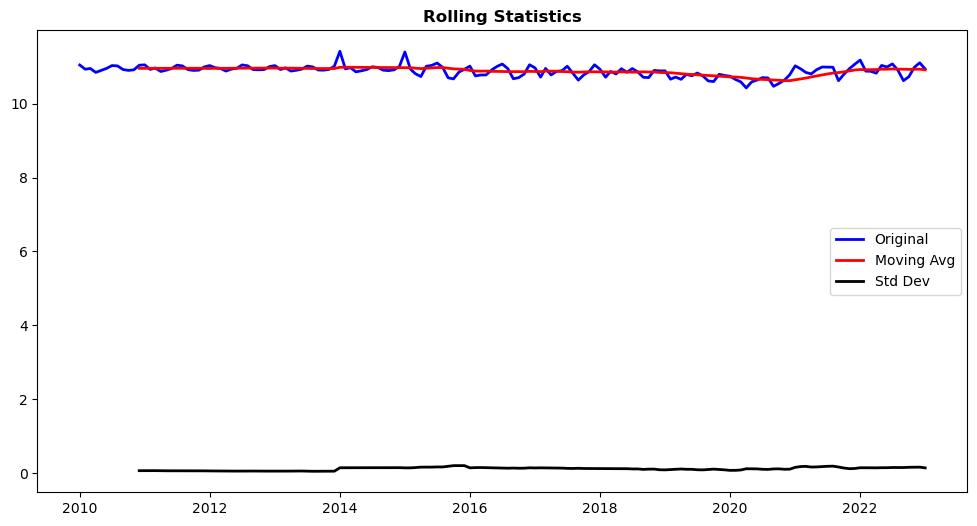


Dickey-Fuller Test Results:

Test Statistic           -1.843231
p-value                   0.359219
Lags Used                12.000000
Observations Used       144.000000
Critical Value (1%)      -3.476598
Critical Value (5%)      -2.881829
Critical Value (10%)     -2.577589
dtype: float64

The series is non-stationary (p >= 0.05).


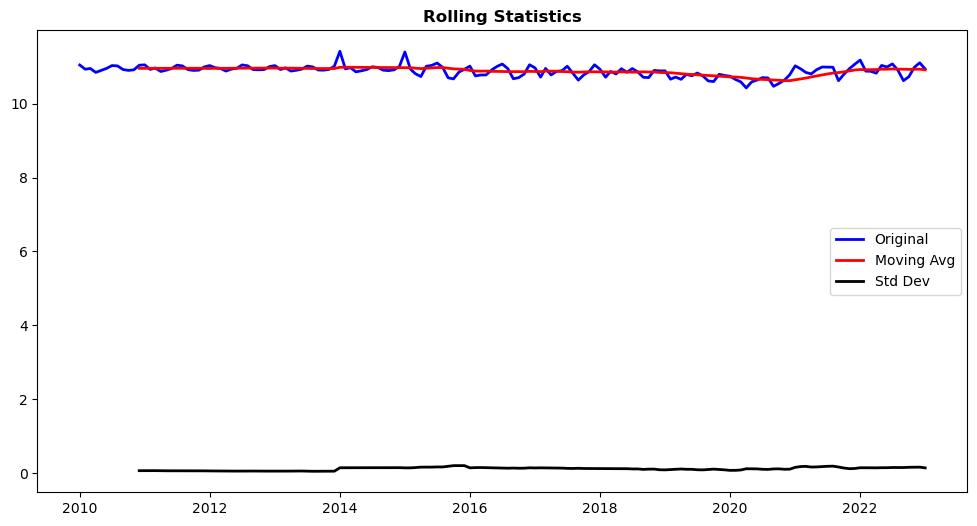


KPSS Test Results:

Test Statistic           1.101273
p-value                  0.010000
Lags Used                5.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64

The series is non-stationary (p < 0.05).


In [31]:
# 44. Execute ADF and KPSS tests to validate stationarity after applying log transformation technique
adf_test_stationarity(df_series['energy_consumption_log'])
kpss_test_stationarity(df_series['energy_consumption_log'])

<p>The <strong>p-value</strong> in <strong>ADF test</strong> & <strong>KPSS test</strong> indicate that the time series continues to be <strong>non-stationary</strong>. Since <strong>Log Transformation technique</strong> was not enough, I'll try <strong>Square Root Transformation</strong> next.</p>

### 2. Square Root Transformation

<p>We should <strong>always</strong> apply simpler techniques first when trying to stationarize data series. If these techniques do not work then we can move forward with more advance techniques or combining different techniques. I'll use <code>np.sqrt()</code> to perform the transformation.</p>

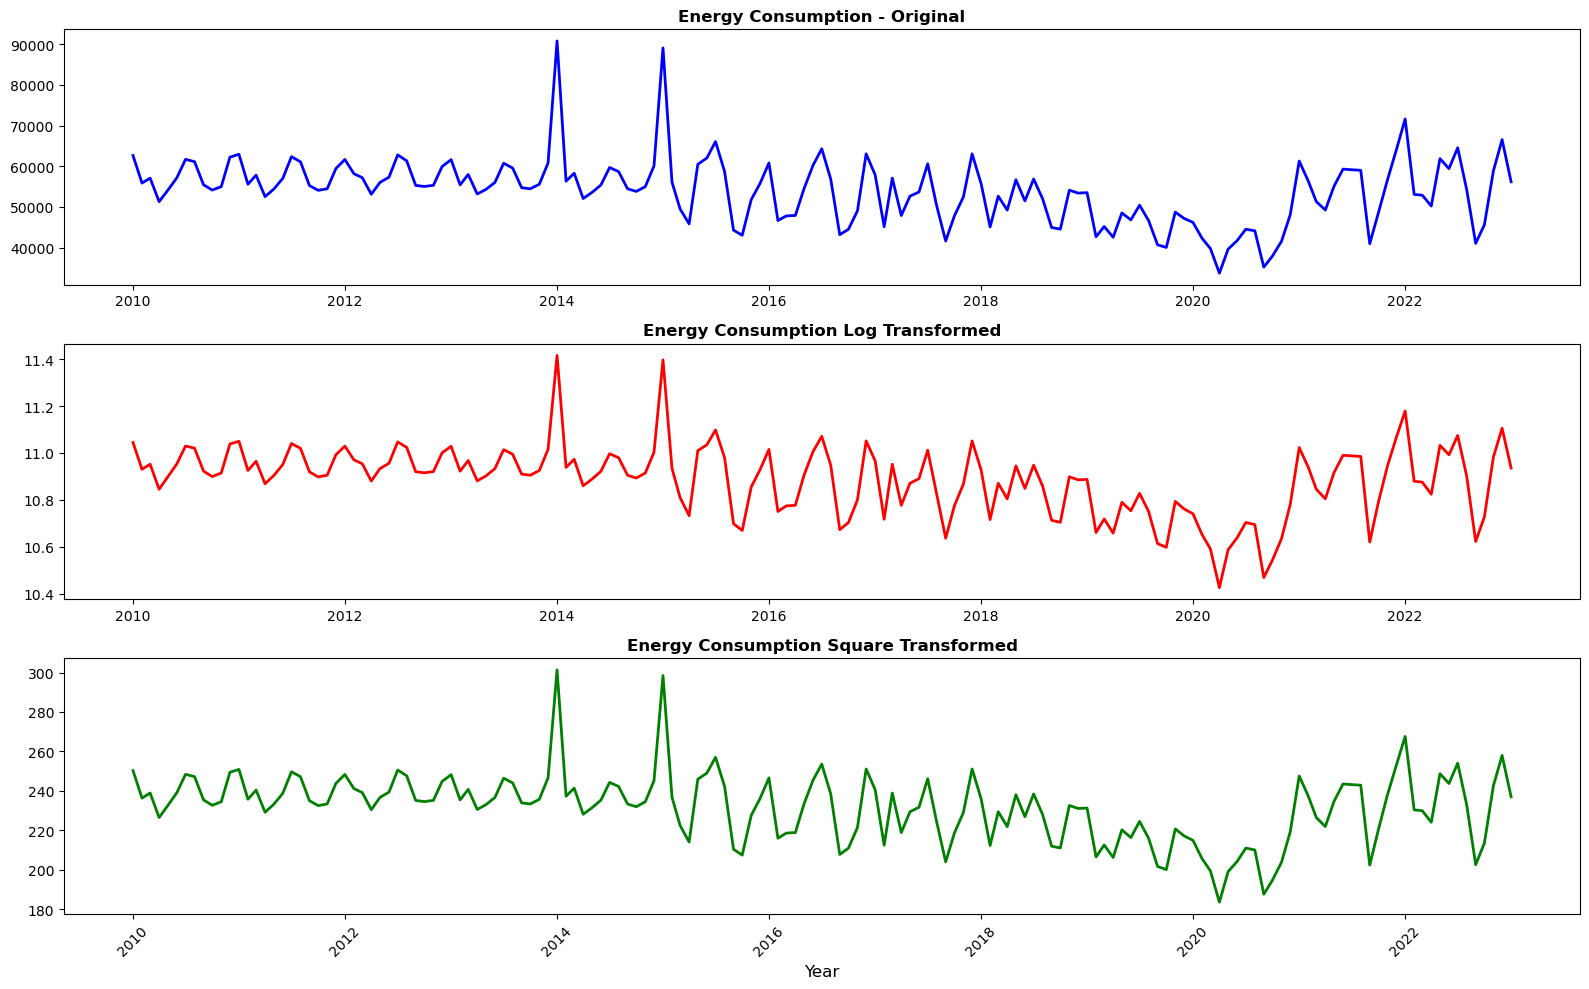

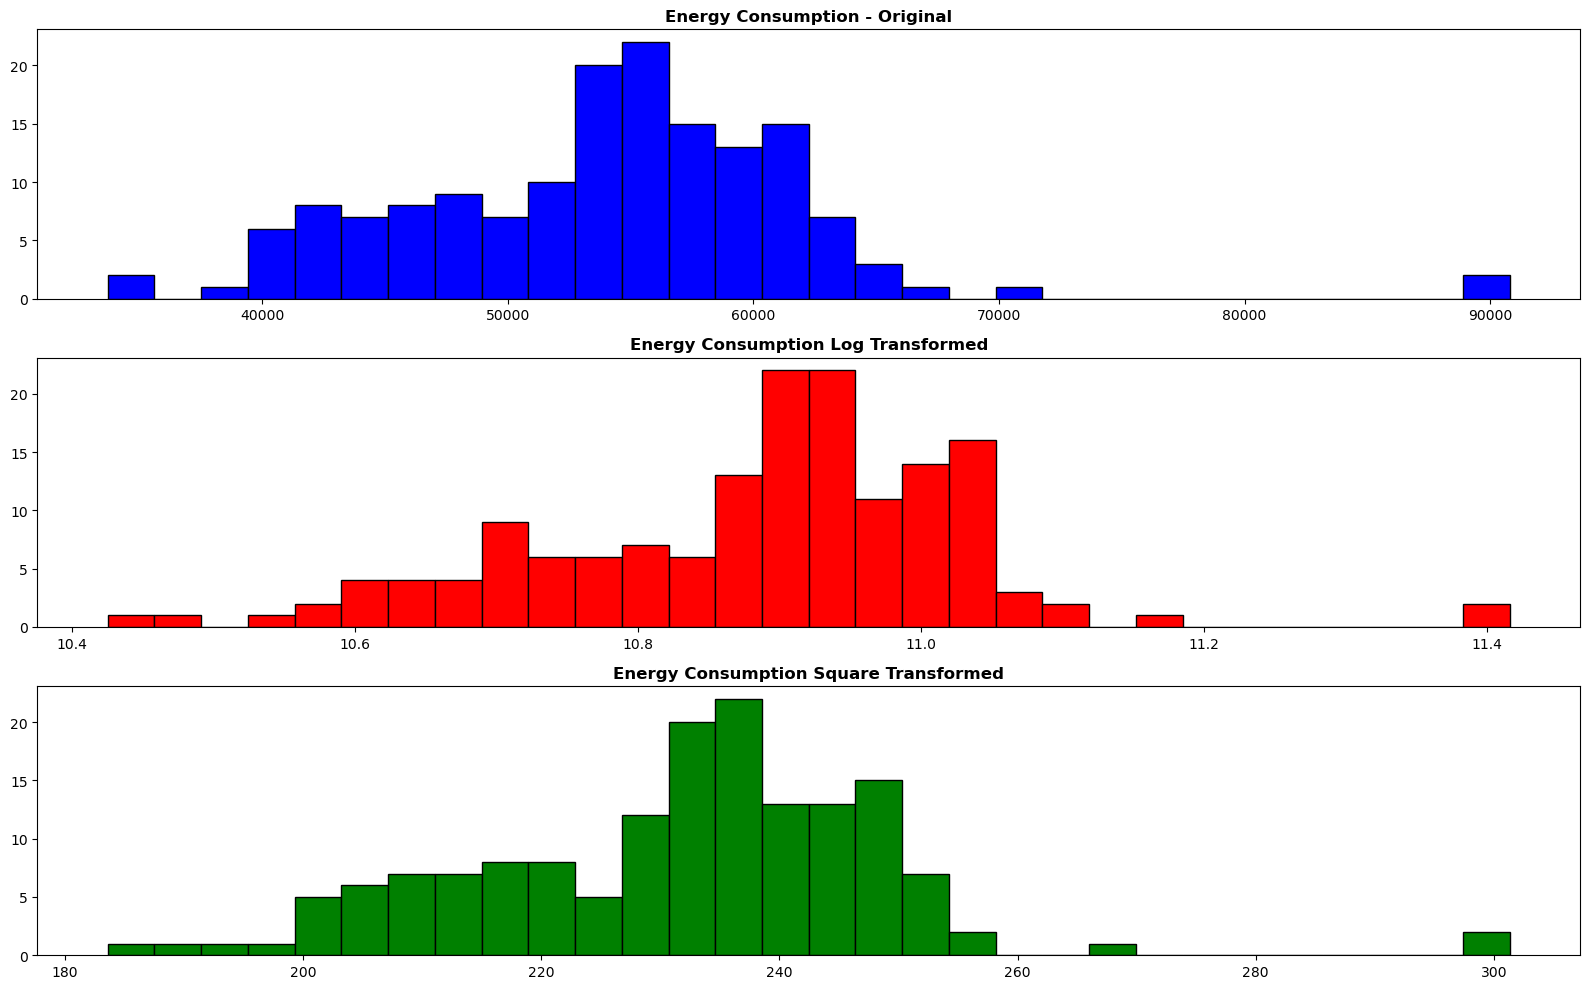

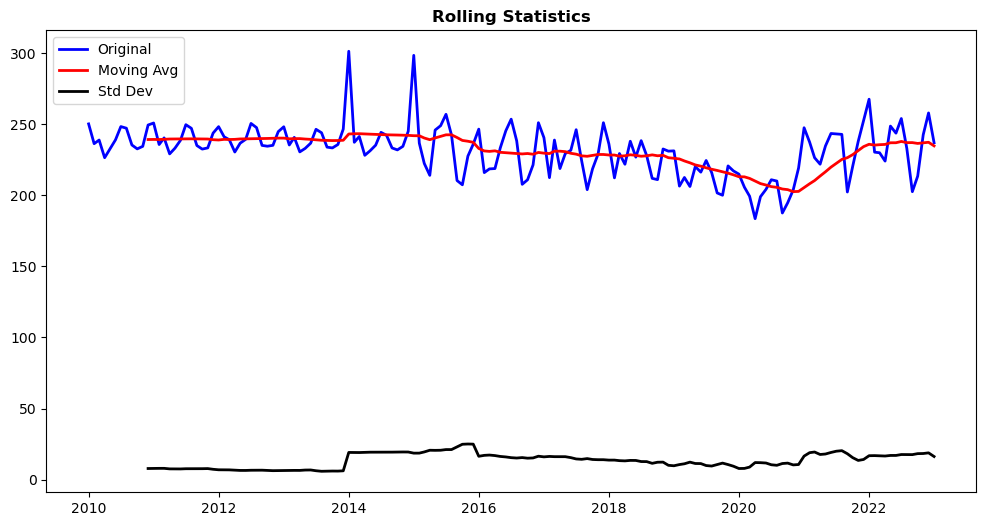


Dickey-Fuller Test Results:

Test Statistic           -1.760308
p-value                   0.400338
Lags Used                12.000000
Observations Used       144.000000
Critical Value (1%)      -3.476598
Critical Value (5%)      -2.881829
Critical Value (10%)     -2.577589
dtype: float64

The series is non-stationary (p >= 0.05).


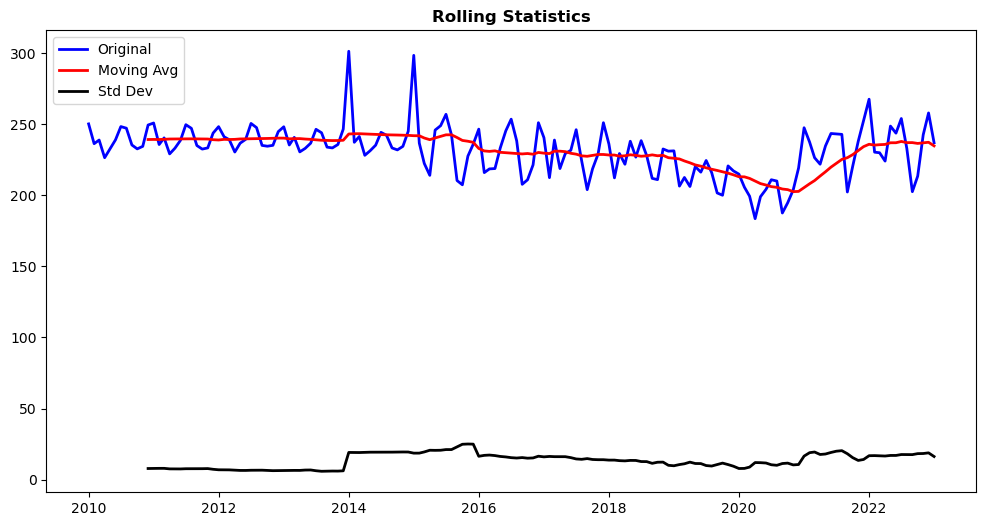


KPSS Test Results:

Test Statistic           1.092678
p-value                  0.010000
Lags Used                5.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64

The series is non-stationary (p < 0.05).


In [32]:
# 45.a Apply square root transformation
df_series['energy_consumption_sqrt'] = np.sqrt(
    df_series['energy_consumption'])

# 45.b Plot transformed time series
plt.subplot(3, 1, 1)
plt.plot(df_series['energy_consumption'], color='blue')
plt.title('Energy Consumption - Original')

# 45.c Plot the log transformation values
plt.subplot(3, 1, 2)
plt.plot(df_series['energy_consumption_log'], color='red')
plt.title('Energy Consumption Log Transformed')

# 45.d Plot the sqrt transformation values
plt.subplot(3, 1, 3)
plt.plot(df_series['energy_consumption_sqrt'], color='green')
plt.title('Energy Consumption Square Transformed')

# 45.e Format x-axis for better visualization
plt.xticks(rotation=45)
plt.xlabel("Year")
plt.tight_layout()
plt.show()


# 45.f Plot histogram of transformed series
plt.subplot(3, 1, 1)
plt.hist(df_series['energy_consumption'], bins=30, edgecolor='black', color='blue')
plt.title('Energy Consumption - Original')

plt.subplot(3, 1, 2)
plt.hist(df_series['energy_consumption_log'], bins=30, edgecolor='black', color='red')
plt.title('Energy Consumption Log Transformed')

plt.subplot(3, 1, 3)
plt.hist(df_series['energy_consumption_sqrt'], bins=30, edgecolor='black', color="green")
plt.title('Energy Consumption Square Transformed')

plt.tight_layout()
plt.show()

# 46. Execute stationarity test on sqrt-transformed data
adf_test_stationarity(df_series['energy_consumption_sqrt'])
kpss_test_stationarity(df_series['energy_consumption_sqrt'])

<p>The time series is still <strong>non-stationary</strong> this means that our second technique, <strong>Square Root Transformation</strong> was not enough to stationarize our data series, these first two techniques are similar, both <strong>Linear Transformations</strong>, and as result, the next technique will be <strong>Box Cox Transformation</strong>.</p>

### 3. Box Cox Transformation

<p>This technique differs from the first two, which are <b>fixed</b>, this third one allows us to control how the transformation is applied through <code>lambda parameter</code>.</p>

In [33]:
# 47. Import Box-Cox transformation function
from scipy.stats import boxcox

# 48.a Apply Box-Cox transformation and find optimal λ
df_series['energy_consumption_box'], lambda_boxcox = boxcox(
    df_series['energy_consumption']
)

# 48.b Display the optimal lambda value
print(f"Optimal Box-Cox lambda: {lambda_boxcox:.4f}")

# 48.c Display first rows of transformed data
df_series.head()

Optimal Box-Cox lambda: 0.2351


,energy_consumption,energy_consumption_log,energy_consumption_sqrt,energy_consumption_box
month,,,,
2010-01-01,62623.196,11.044891,250.246271,52.828068
2010-02-01,55850.217,10.930429,236.326505,51.312412
2010-03-01,57069.645,10.952028,238.892539,51.595302
2010-04-01,51282.697,10.845109,226.456833,50.208884
2010-05-01,54092.590,10.898452,232.578137,50.896236


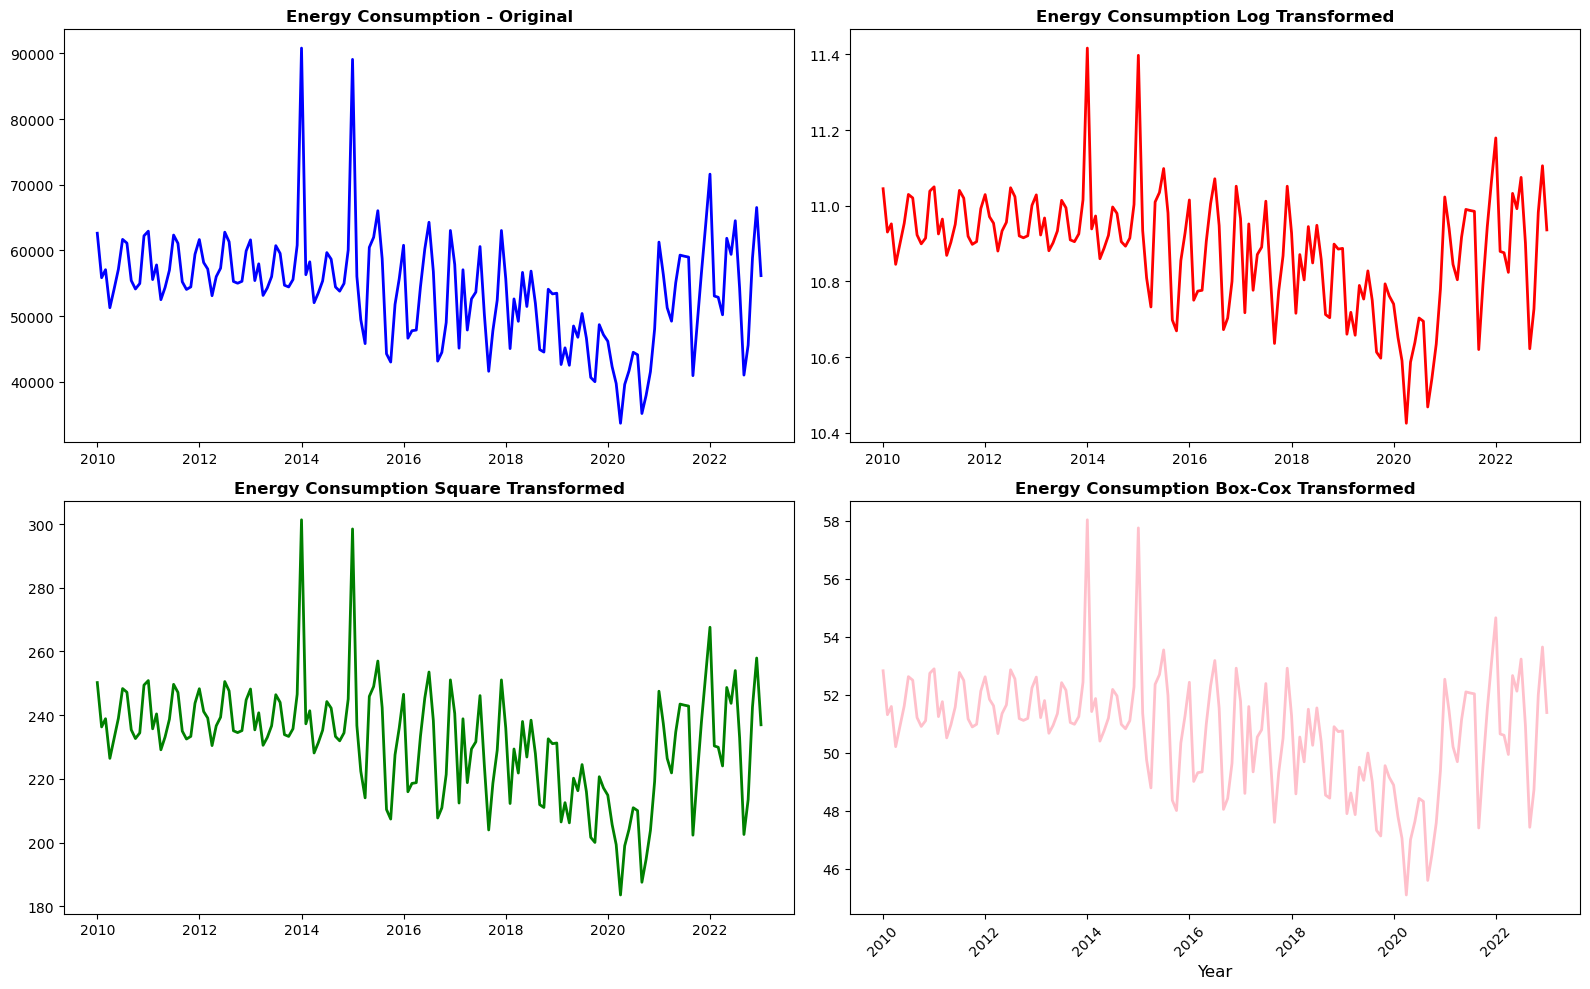

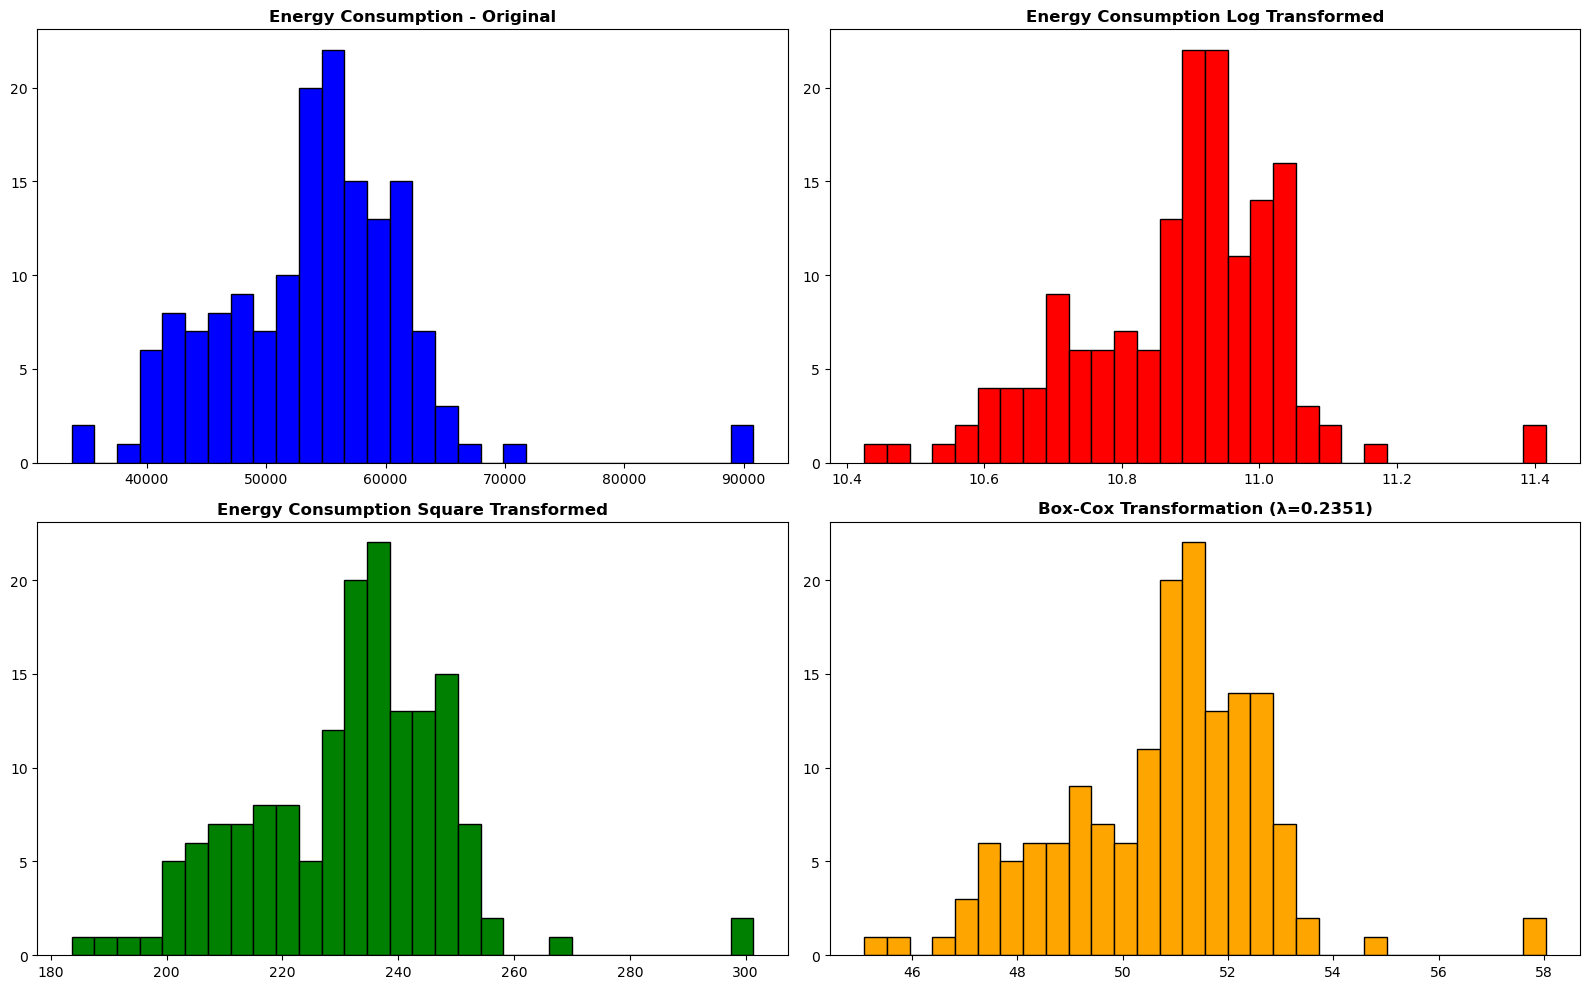

In [34]:
# 48.d Plot transformed time series
plt.subplot(2, 2, 1)
plt.plot(df_series['energy_consumption'], color='blue')
plt.title('Energy Consumption - Original')

# 48.e Plot the log transformation values
plt.subplot(2, 2, 2)
plt.plot(df_series['energy_consumption_log'], color='red')
plt.title('Energy Consumption Log Transformed')

# 48.f Plot the sqrt transformation values
plt.subplot(2, 2, 3)
plt.plot(df_series['energy_consumption_sqrt'], color='green')
plt.title('Energy Consumption Square Transformed')

# 48.g Plot the Box Cox transformation values
plt.subplot(2, 2, 4)
plt.plot(df_series['energy_consumption_box'], color='pink')
plt.title('Energy Consumption Box-Cox Transformed')

# 48.h Format x-axis for better visualization
plt.xticks(rotation=45)
plt.xlabel("Year")
plt.tight_layout()
plt.show()


# 48.i Plot histogram of transformed series
plt.subplot(2, 2, 1)
plt.hist(df_series['energy_consumption'], bins=30, edgecolor='black', color='blue')
plt.title('Energy Consumption - Original')

plt.subplot(2, 2, 2)
plt.hist(df_series['energy_consumption_log'], bins=30, edgecolor='black', color='red')
plt.title('Energy Consumption Log Transformed')

plt.subplot(2, 2, 3)
plt.hist(df_series['energy_consumption_sqrt'], bins=30, edgecolor='black', color="green")
plt.title('Energy Consumption Square Transformed')

plt.subplot(2, 2, 4)
plt.hist(df_series['energy_consumption_box'], bins=30, edgecolor='black', color="orange")
plt.title('Energy Consumption Box-Cox Transformed')
plt.title(f"Box-Cox Transformation (λ={lambda_boxcox:.4f})")

plt.tight_layout()
plt.show()

<p>I still don't see any significant changes neither in the transformed values nor the histogram. But let's validate with the stationary tests as we can not rely solely on visual inspection.</p>

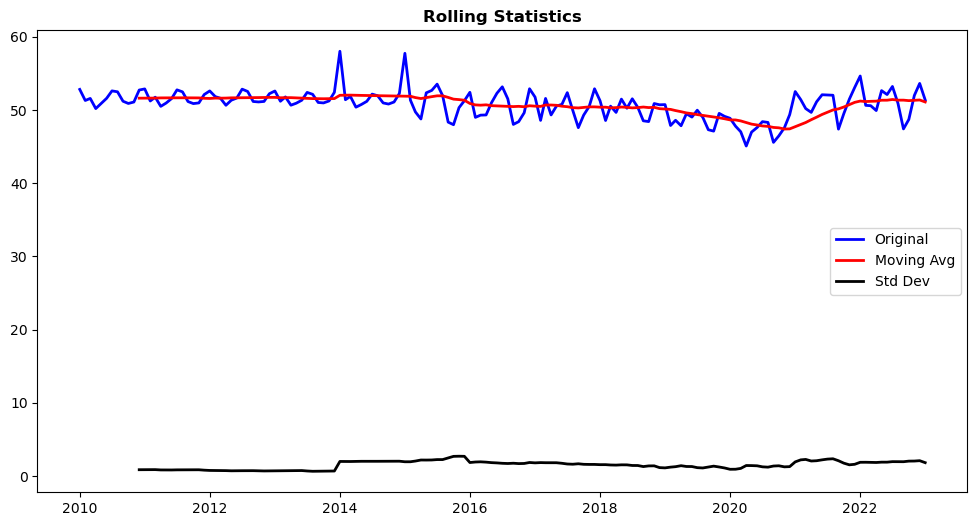


Dickey-Fuller Test Results:

Test Statistic           -1.804425
p-value                   0.378267
Lags Used                12.000000
Observations Used       144.000000
Critical Value (1%)      -3.476598
Critical Value (5%)      -2.881829
Critical Value (10%)     -2.577589
dtype: float64

The series is non-stationary (p >= 0.05).


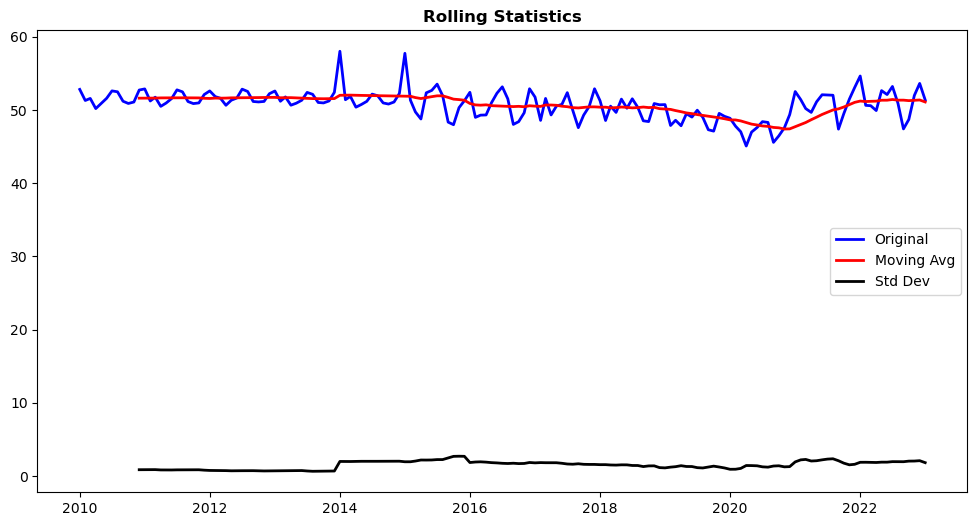


KPSS Test Results:

Test Statistic           1.098148
p-value                  0.010000
Lags Used                5.000000
Critical Value (10%)     0.347000
Critical Value (5%)      0.463000
Critical Value (2.5%)    0.574000
Critical Value (1%)      0.739000
dtype: float64

The series is non-stationary (p < 0.05).


In [35]:
# 49. Run the stationary tests
adf_test_stationarity(df_series['energy_consumption_box'])
kpss_test_stationarity(df_series['energy_consumption_box'])

<p><strong>Box Cox Transformation</strong> is still not enough to convert our time series to stationary. With some data series we must apply a combination of several techniques; in other words, in some cases we need to apply one technique to the result of another one.</p>

### 4. Smoothing with Simple Moving Average

<p>Next, I'll try with the technique <strong> Smoothing with Simple Moving Average</strong>. Here, we calculate the <strong>mean of the last K values</strong>, depending on the series frequency.</p>

In [36]:
# 50.a Compute the mean of the time series
series_mean = df_series.mean()
print(series_mean)

energy_consumption         53956.577204
energy_consumption_log        10.884849
energy_consumption_sqrt      231.643956
energy_consumption_box        50.753952
dtype: float64


<p>This is just <strong>overall mean</strong> of the energy consumption variable. A <strong>moving average</strong> is calculated by using the <code>rolling()</code> function, which <strong>creates a sliding window</strong> over the data. Let's make a copy of the data I have so far before continuing.</p>

In [37]:
# 50.b Create a copy of the original time series
df_series_copy = df_series.copy()

<p>Next, I'm going to calculate the <strong>the simple moving average</strong>.</p>

In [38]:
# 50.c Apply a 12-month moving average
df_series['energy_consumption_smoothed'] = (
    df_series['energy_consumption']
    .rolling(12)
    .mean()
)

# 50.d Display the dataset with the smoothed series
df_series

,energy_consumption,energy_consumption_log,energy_consumption_sqrt,energy_consumption_box,energy_consumption_smoothed
month,,,,,
2010-01-01,62623.1960,11.044891,250.246271,52.828068,NaN
2010-02-01,55850.2170,10.930429,236.326505,51.312412,NaN
2010-03-01,57069.6450,10.952028,238.892539,51.595302,NaN
2010-04-01,51282.6970,10.845109,226.456833,50.208884,NaN
2010-05-01,54092.5900,10.898452,232.578137,50.896236,NaN
...,...,...,...,...,...
2022-09-01,41031.7113,10.622100,202.562858,47.426901,56490.901183
2022-10-01,45584.7710,10.727329,213.505904,48.721440,56241.319267
2022-11-01,58841.7691,10.982607,242.573224,51.998279,56426.282558


<p>We now have <code>NaN</code> values. This is a result of this technique and it's caused because the moving window needs 12 months of data to calculate the average. For the first 12 records there aren't enough values so the calculation doesn't happen until the 12th month, this causes data loss which is important to have in mind if we're using this technique to solve the stationary issue. Now let's plot the original data and the smoothed data.</p>

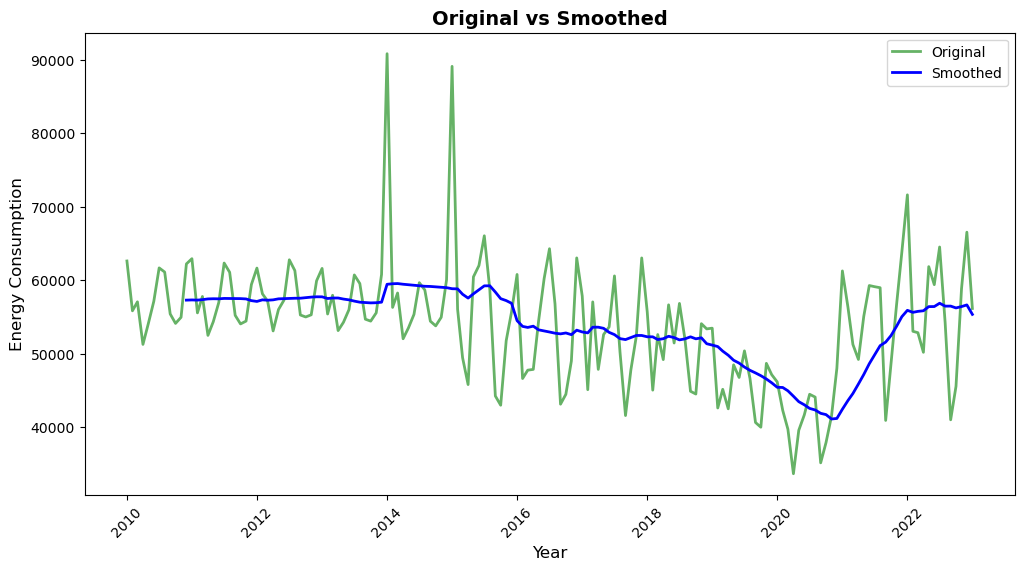

In [39]:
# 51.a Plot original and smoothed series
plt.figure(figsize=(12, 6))

# 51.b Plot original series
plt.plot(df_series.index, 
         df_series['energy_consumption'], 
         color='green', linewidth=2, 
         alpha=0.6, label='Original')

# 51.c Plot smoothed series
plt.plot(df_series.index, 
         df_series['energy_consumption_smoothed'], 
         color='blue', linewidth=2, 
         label='Smoothed')

# 51.d Customize plot aesthetics
plt.xticks(rotation=45)
plt.xlabel("Year")
plt.ylabel("Energy Consumption")
plt.title("Original vs Smoothed", fontsize=14, 
          fontweight='bold')
plt.grid(False)
plt.legend()
plt.show()

<p>The graph shows no significant data loss, both values, original and smoothed, follows the same trend in energy consumption. Next, I'll <strong>calculate the difference</strong> between the <b>original</b> and <b>smoothed</b> values. This will <b>remove the trend</b> and will only keep the <b>seasonality</b>.</p>

In [40]:
# 52.a Compute the difference between original and smoothed series to remove trend
diff_original_smoothed = (
    df_series['energy_consumption'] - 
    df_series['energy_consumption_smoothed']
)

# 52.b Display first 20 records
diff_original_smoothed.head(20)

month
2010-01-01            NaN
2010-02-01            NaN
2010-03-01            NaN
2010-04-01            NaN
2010-05-01            NaN
2010-06-01            NaN
2010-07-01            NaN
2010-08-01            NaN
2010-09-01            NaN
2010-10-01            NaN
2010-11-01            NaN
2010-12-01    4922.388833
2011-01-01    5609.589417
2011-02-01   -1735.921917
2011-03-01     432.235417
2011-04-01   -4958.359417
2011-05-01   -3119.604917
2011-06-01    -484.783750
2011-07-01    4810.336250
2011-08-01    3554.251750
dtype: float64

<p>These initial values are lost, so there's no case in leaving them. I'll go ahead and remove them and then perform the stationarity tests.</p>

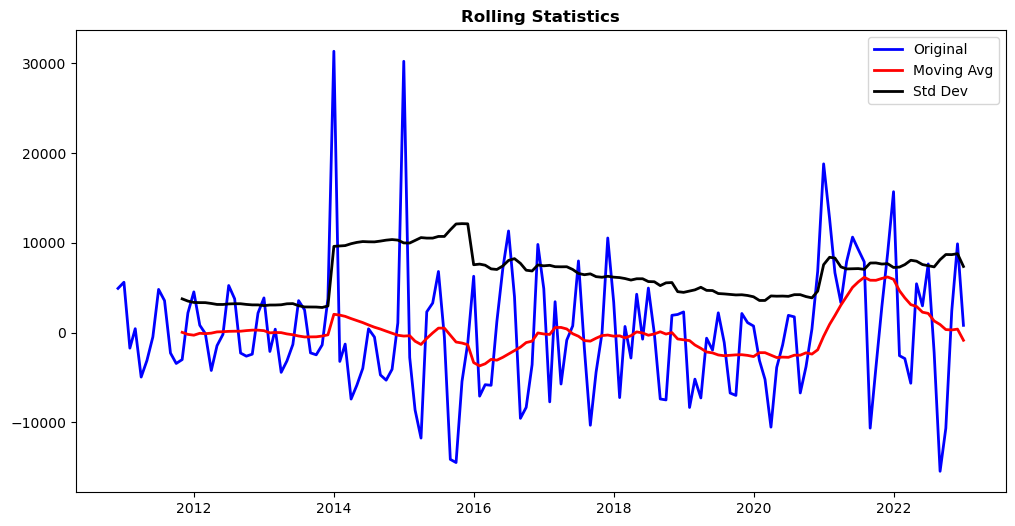


Dickey-Fuller Test Results:

Test Statistic           -2.530582
p-value                   0.108210
Lags Used                12.000000
Observations Used       133.000000
Critical Value (1%)      -3.480500
Critical Value (5%)      -2.883528
Critical Value (10%)     -2.578496
dtype: float64

The series is non-stationary (p >= 0.05).


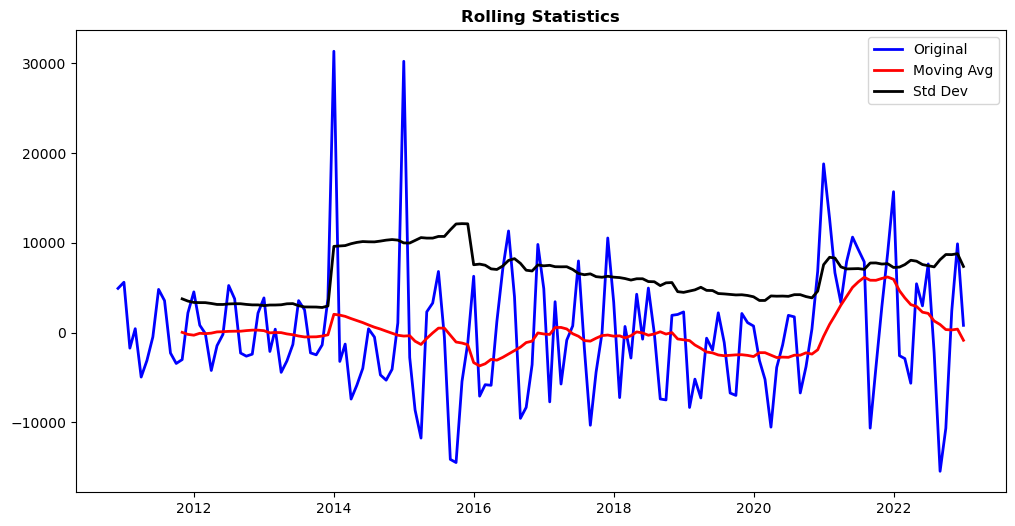


KPSS Test Results:

Test Statistic            0.110845
p-value                   0.100000
Lags Used                14.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64

The series is stationary (p >= 0.05).


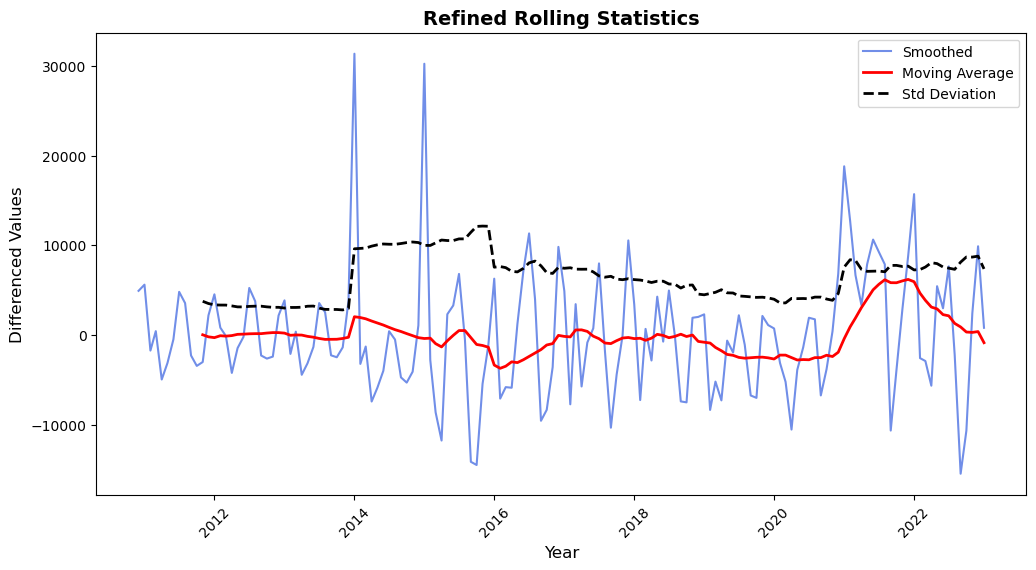

In [41]:
# 53.a Remove NaN and infinite values
diff_original_smoothed = diff_original_smoothed.dropna()
diff_original_smoothed = diff_original_smoothed[
    ~np.isinf(diff_original_smoothed)
]

# 53.b Execute stationarity test
adf_test_stationarity(diff_original_smoothed)
kpss_test_stationarity(diff_original_smoothed)

# 53.c Refined plot for rolling statistics
plt.figure(figsize=(12, 6))

# 53.d Plot original smoothed series
plt.plot(diff_original_smoothed, color='royalblue', 
         linewidth=1.5, alpha=0.75, label='Smoothed')

# 53.e Compute rolling mean and standard deviation
rolling_mean = diff_original_smoothed.rolling(
    window=12).mean()
rolling_std = diff_original_smoothed.rolling(
    window=12).std()

# 53.f Plot rolling mean and std deviation
plt.plot(rolling_mean, color='red', linewidth=2, 
         label='Moving Average')
plt.plot(rolling_std, color='black', linewidth=2, 
         linestyle='dashed', label='Std Deviation')

# 53.g Customize visualization aesthetics
plt.xticks(rotation=45)
plt.xlabel("Year")
plt.ylabel("Differenced Values")
plt.title("Refined Rolling Statistics", fontsize=14, 
          fontweight='bold')
plt.legend()
plt.grid(False)
plt.show()

<p>Now the <strong>KPSS test</strong> indicates that the time series is stationary; however, the <strong>ADF test</strong> doesn't, this means that the time series is <strong>trend-stationary</strong> or possesses <strong>structural breaks</strong>. I'll move to another technique.</p>

### 5. Exponential Weighted Moving Average (EWMA)

<p>The <strong>Exponential Weighted Moving Average (EWMA)</strong> gives more weight to recent values. This technique is applied by using <code>ewm()</code> function in Pandas. Now, let's see if this method yields better results.</p>

In [42]:
# 54.a Apply exponential smoothing to the original series
df_series['energy_consumption_exp'] = (
    df_series['energy_consumption']
    .ewm(alpha=0.2, adjust=True)
    .mean()
)

# 54.b Display the smoothed series
df_series['energy_consumption_exp'].head()

month
2010-01-01    62623.196000
2010-02-01    58860.429889
2010-03-01    58126.501656
2010-04-01    55808.139645
2010-05-01    55297.802411
Name: energy_consumption_exp, dtype: float64

<p>Let's plot the data to visualize the effects of this method.</p>

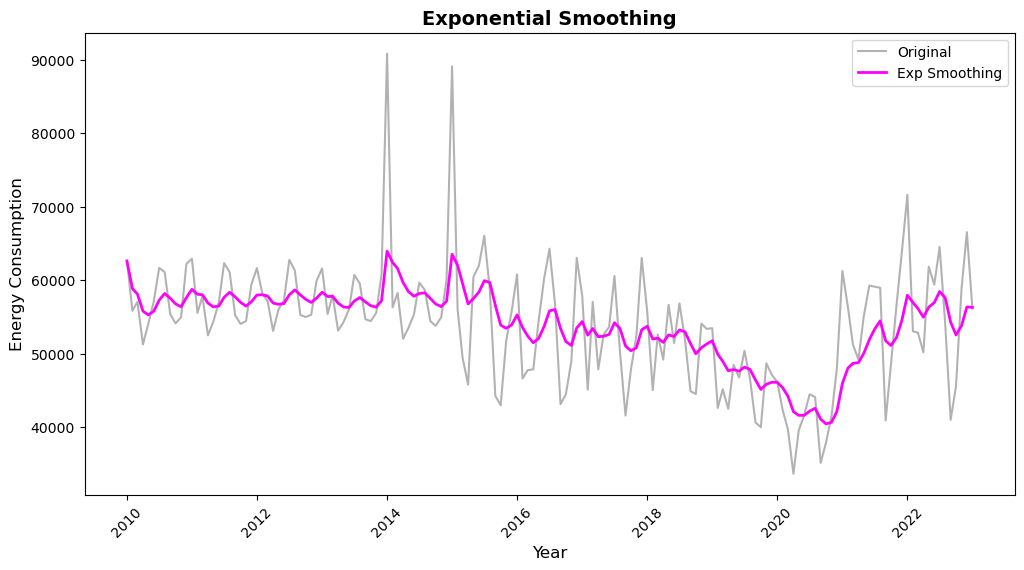

In [43]:
# 54.c Plot original and exponentially smoothed series
plt.figure(figsize=(12, 6))

# 54.d Plot original series
plt.plot(df_series.index, df_series['energy_consumption'], 
         color='gray', linewidth=1.5, alpha=0.6, 
         label='Original')

# 54.e Plot exponentially smoothed series
plt.plot(df_series.index, df_series['energy_consumption_exp'], 
         color='magenta', linewidth=2, label='Exp Smoothing')

# 54.f Customize visualization
plt.xticks(rotation=45)
plt.xlabel("Year")
plt.ylabel("Energy Consumption")
plt.title("Exponential Smoothing", fontsize=14, 
          fontweight='bold')
plt.legend()
plt.grid(False)
plt.show()

<p>The pink line, the result of <strong>EWMA method</strong>, is not as flat as before so, this means that it still retains some seasonality from the original series and better follow the series pattern. This might suggest <strong>EWMA</strong> is not ideal for the time series but, let's apply differencing to confirm.</p>

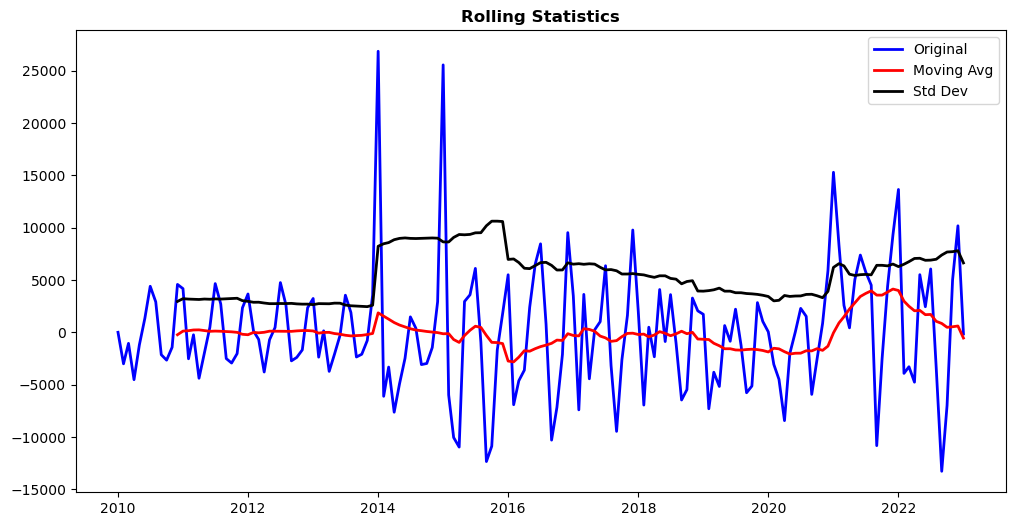


Dickey-Fuller Test Results:

Test Statistic           -2.625102
p-value                   0.087919
Lags Used                12.000000
Observations Used       144.000000
Critical Value (1%)      -3.476598
Critical Value (5%)      -2.881829
Critical Value (10%)     -2.577589
dtype: float64

The series is non-stationary (p >= 0.05).


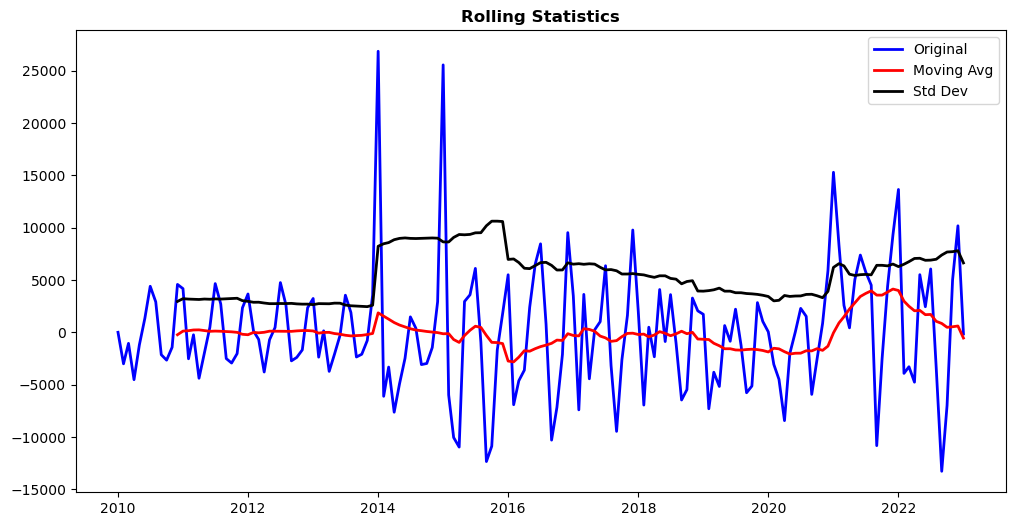


KPSS Test Results:

Test Statistic            0.189404
p-value                   0.100000
Lags Used                50.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64

The series is stationary (p >= 0.05).


In [44]:
# 55.a Compute the difference between original and exponentially smoothed series
diff_original_exp_smooth = (
    df_series['energy_consumption'] - 
    df_series['energy_consumption_exp']
)

# 55.b Remove NaN values before testing stationarity
diff_original_exp_smooth.dropna(inplace=True)

# 55.c Execute stationarity test
adf_test_stationarity(diff_original_exp_smooth)
kpss_test_stationarity(diff_original_exp_smooth)

<p>Again, contradictory results between <strong>ADF test</strong> and <strong>KPSS test</strong> so, this method is not enough to fully stationarize our data series. Let's move to the next one</p>

### 6. Differencing to Remove Trend

<p>I'll try now <strong>differencing</strong> to remove <strong>trend and seasonality</strong>.<br>First we must apply <b>Log Transformation</b> to normalize the scale. Since data must be in the same scale for accurate results.</p>

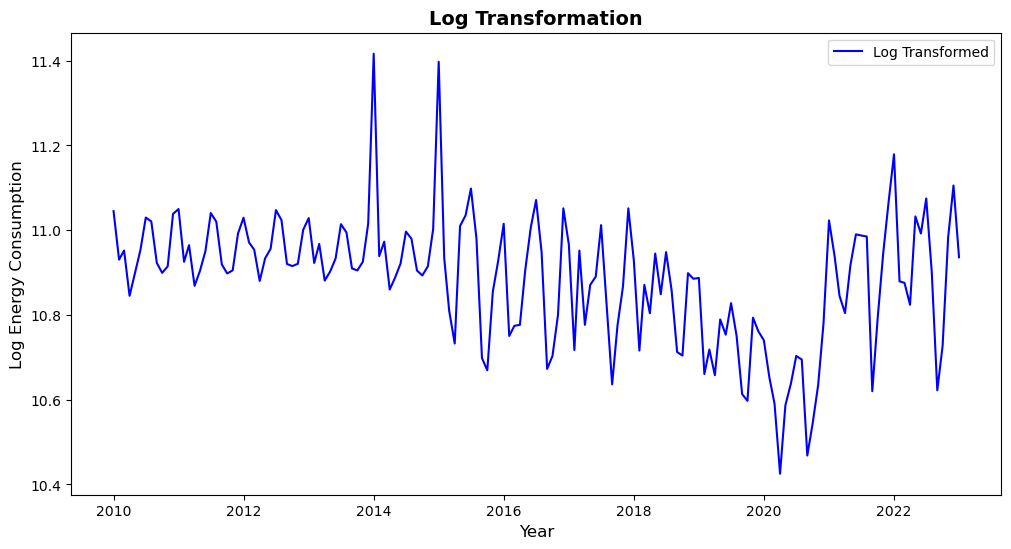

In [45]:
# 56.a Apply log transformation to normalize scale
df_series['energy_consumption_log'] = np.log(
    df_series['energy_consumption']
)

# 56.b Plot log-transformed series
plt.figure(figsize=(12, 6))
plt.plot(df_series.index, 
         df_series['energy_consumption_log'], 
         color='blue', linewidth=1.5, 
         label='Log Transformed')
plt.xlabel("Year")
plt.ylabel("Log Energy Consumption")
plt.title("Log Transformation", fontsize=14, 
          fontweight='bold')
plt.legend()
plt.grid(False)
plt.show()

<p>This is the same technique as before; however, this time I'll combine it with differencing and see if that helps to achieve our main goal.</p>

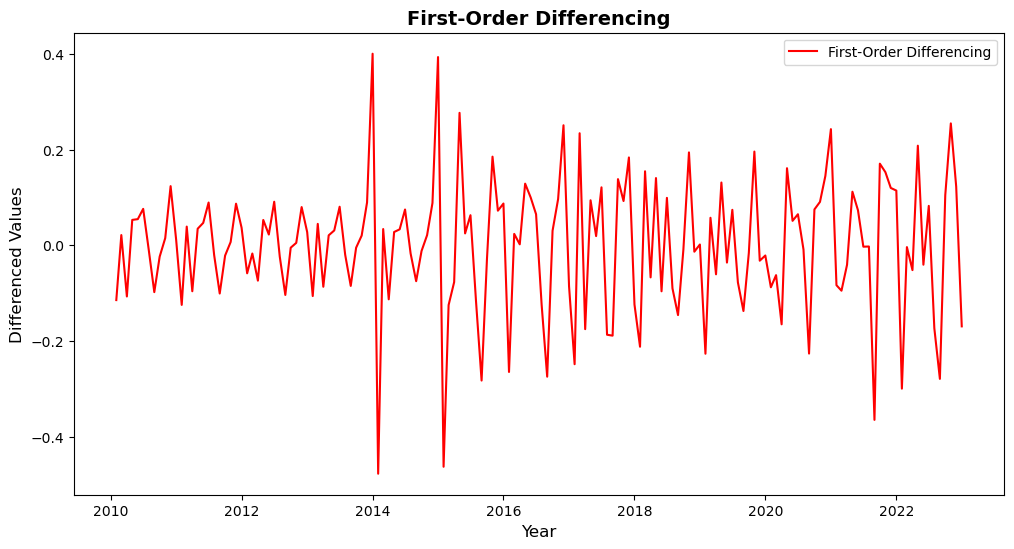

In [46]:
# 57.a Compute first-order differencing 
df_series['energy_consumption_diff1'] = (
    df_series['energy_consumption_log'] - 
    df_series['energy_consumption_log'].shift()
)

# 57.b Plot first-order differenced series
plt.figure(figsize=(12, 6))
plt.plot(df_series.index, 
         df_series['energy_consumption_diff1'], 
         color='red', linewidth=1.5, 
         label='First-Order Differencing')
plt.xlabel("Year")
plt.ylabel("Differenced Values")
plt.title("First-Order Differencing", fontsize=14, 
          fontweight='bold')
plt.legend()
plt.grid(False)
plt.show()

<p>The result is a complete change for our time series and the information is preserved. With the first order differencing I have removed trend and I'll remove seasonality with a second differencing. Let's put the results into a Pandas DataFrame and test the stationarity again.</p>

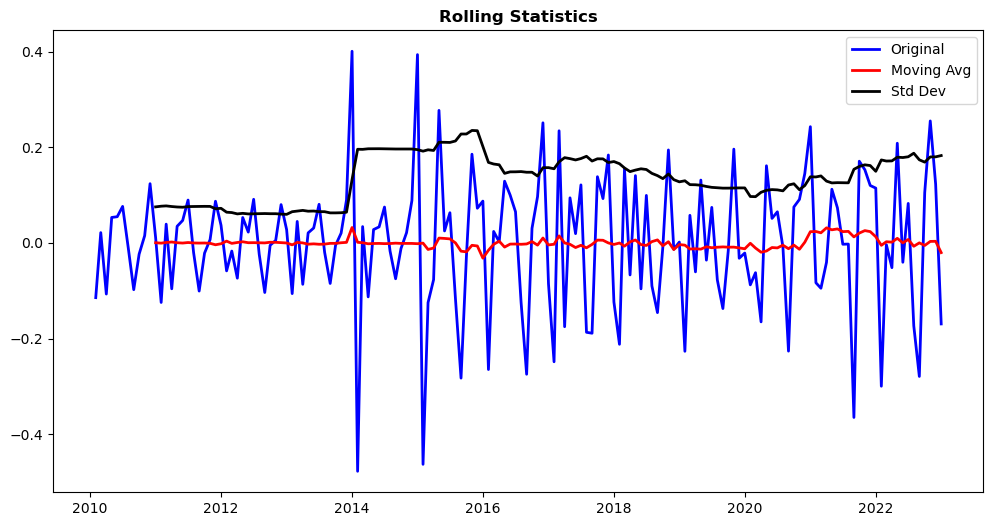


Dickey-Fuller Test Results:

Test Statistic           -3.962978
p-value                   0.001617
Lags Used                11.000000
Observations Used       144.000000
Critical Value (1%)      -3.476598
Critical Value (5%)      -2.881829
Critical Value (10%)     -2.577589
dtype: float64

The series is stationary (p < 0.05).


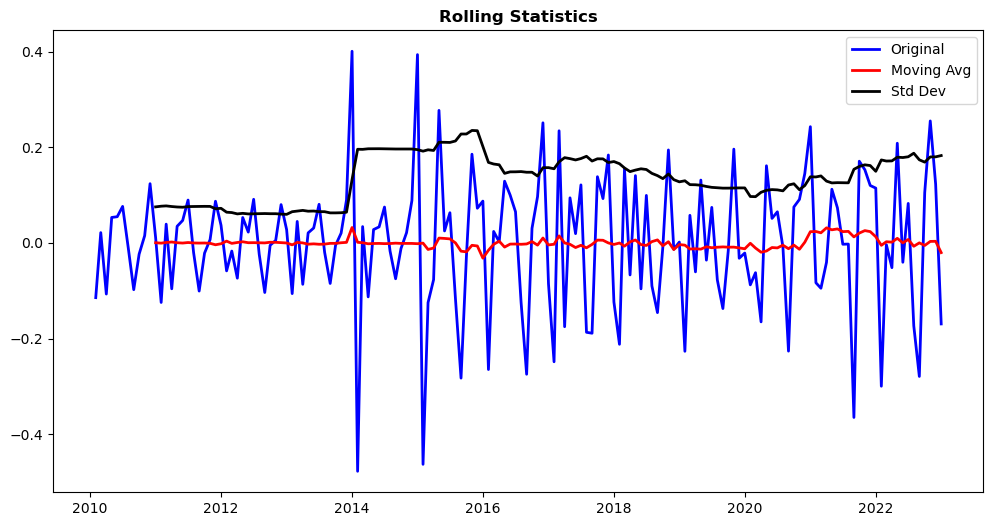


KPSS Test Results:

Test Statistic            0.119567
p-value                   0.100000
Lags Used                24.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64

The series is stationary (p >= 0.05).


In [47]:
# 58.a Convert differenced list to DataFrame
df_series_diff1 = pd.DataFrame(
    data=df_series['energy_consumption_diff1'].dropna().values,
    index=df_series['energy_consumption_diff1'].dropna().index, 
    columns=['Differenced_Series']
)

# 58.b Test stationarity after differencing
adf_test_stationarity(df_series_diff1)
kpss_test_stationarity(df_series_diff1)

<p>We have <strong>finally achieved stationarity</strong> now, after applying two techniques sequentialy, first using <strong>Log Transformation</strong> and then <strong>Differencing</strong> to remove trend. However, if this was not enough I would proceed to remove, <b>seasonality</b>, as well; but, not required in this case.</p>

In [48]:
"""
# 59.a Compute second-order differencing to remove seasonality
df_series['energy_consumption_diff2'] = (
    df_series['energy_consumption_diff1'].diff()
)

# 59.b Apply second differencing to remove seasonality
df_series_diff2 = pd.DataFrame(
    data=df_series['energy_consumption_diff2'].dropna().values,
    index=df_series['energy_consumption_diff2'].dropna().index,  # Adjust index for second differencing
    columns=['Differenced_Series']
)

# 59.c Plot the second differenced series
plt.figure(figsize=(12, 6))
plt.plot(df_series_diff2.index, df_series_diff2, color='green', lw=1.5, label='Second Differencing - Seasonality Removed')
plt.xlabel("Year")
plt.ylabel("Differenced Values")
plt.title("Second Differencing for Seasonality", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(False)
plt.show()
"""

'\n# 59.a Compute second-order differencing to remove seasonality\ndf_series[\'energy_consumption_diff2\'] = (\n    df_series[\'energy_consumption_diff1\'].diff()\n)\n\n# 59.b Apply second differencing to remove seasonality\ndf_series_diff2 = pd.DataFrame(\n    data=df_series[\'energy_consumption_diff2\'].dropna().values,\n    index=df_series[\'energy_consumption_diff2\'].dropna().index,  # Adjust index for second differencing\n    columns=[\'Differenced_Series\']\n)\n\n# 59.c Plot the second differenced series\nplt.figure(figsize=(12, 6))\nplt.plot(df_series_diff2.index, df_series_diff2, color=\'green\', lw=1.5, label=\'Second Differencing - Seasonality Removed\')\nplt.xlabel("Year")\nplt.ylabel("Differenced Values")\nplt.title("Second Differencing for Seasonality", fontsize=14, fontweight=\'bold\')\nplt.legend()\nplt.grid(False)\nplt.show()\n'

In [49]:
"""
# 60. Test stationarity after second differencing
adf_test_stationarity(df_series_diff2)
kpss_test_stationarity(df_series_diff2)
"""

'\n# 60. Test stationarity after second differencing\nadf_test_stationarity(df_series_diff2)\nkpss_test_stationarity(df_series_diff2)\n'

### Forecasting with ARIMA model

In [50]:
# 59. Create a function to find best parameters for SARIMAX model
def AIC_PDQS(data):
    """
    Runs grid search to return lowest AIC results for permutations of pdq/s values
    Args:
        data: TimeSeriesData to analyze for best pdq/s permutations.
    Return:
        It returns the best pdq/s permutation found.
    """
    import statsmodels.api as sm
    import itertools
    import warnings
    warnings.filterwarnings("ignore")
    
    # 59.a Define the range for p, d and q parameters
    p = d = q = range(0, 3)
    # 59.b Generate all different combinations of p, d, q triplets
    pdq = list(itertools.product(p, d, q))

    # 59.c Generate all different combinations of seasonal p, d, q triplets
    pdqs = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

    # 59.d Run a grid with pdq and seasonal pdq parameters calculated above and get the best AIC value
    ans = []
    for comb in pdq:
        for combs in pdqs:
            try:
                model = sm.tsa.statespace.SARIMAX(data,
                                                  order=comb,
                                                  seasonal=combs,
                                                  enforce_stationarity=False,
                                                  enforce_invertibility=False)
                output = model.fit(disp='False')
                ans.append([comb, combs, output.aic])
                print(f'ARIMA {comb} x {combs}12 : AIC Calculated ={output.aic}')
            except:
                continue

    # 59.e Find the best params with minimal AIC value
    ans_data = pd.DataFrame(ans, columns=['pdq', 'PDQS', 'AIC_score'])
    print(ans_data.loc[ans_data['AIC_score'].idxmin()])
    return ans_data

In [51]:
# 60.a Split the data into train and test sets
from pmdarima.model_selection import train_test_split
train, test = train_test_split(df_series_diff1['Differenced_Series'].dropna(), test_size=0.25)

# 60.b Calling the AIC_PDQS function for hyperparameters
AIC_PDQS(train)

ARIMA (0, 0, 0) x (0, 0, 0, 12)12 : AIC Calculated =-133.51439916149786
ARIMA (0, 0, 0) x (0, 0, 1, 12)12 : AIC Calculated =-133.51439916149786
ARIMA (0, 0, 0) x (0, 0, 2, 12)12 : AIC Calculated =-133.51439916149786
ARIMA (0, 0, 0) x (0, 1, 0, 12)12 : AIC Calculated =-133.51439916149786
ARIMA (0, 0, 0) x (0, 1, 1, 12)12 : AIC Calculated =-133.51439916149786
ARIMA (0, 0, 0) x (0, 1, 2, 12)12 : AIC Calculated =-133.51439916149786
ARIMA (0, 0, 0) x (0, 2, 0, 12)12 : AIC Calculated =-133.51439916149786
ARIMA (0, 0, 0) x (0, 2, 1, 12)12 : AIC Calculated =-133.51439916149786
ARIMA (0, 0, 0) x (0, 2, 2, 12)12 : AIC Calculated =-133.51439916149786
ARIMA (0, 0, 0) x (1, 0, 0, 12)12 : AIC Calculated =-133.51439916149786
ARIMA (0, 0, 0) x (1, 0, 1, 12)12 : AIC Calculated =-133.51439916149786
ARIMA (0, 0, 0) x (1, 0, 2, 12)12 : AIC Calculated =-133.51439916149786
ARIMA (0, 0, 0) x (1, 1, 0, 12)12 : AIC Calculated =-133.51439916149786
ARIMA (0, 0, 0) x (1, 1, 1, 12)12 : AIC Calculated =-133.5143991

,pdq,PDQS,AIC_score
0,"(0, 0, 0)","(0, 0, 0, 12)",-133.514399
1,"(0, 0, 0)","(0, 0, 1, 12)",-133.514399
2,"(0, 0, 0)","(0, 0, 2, 12)",-133.514399
3,"(0, 0, 0)","(0, 1, 0, 12)",-133.514399
4,"(0, 0, 0)","(0, 1, 1, 12)",-133.514399
...,...,...,...
724,"(2, 2, 2)","(2, 1, 1, 12)",-111.511541
725,"(2, 2, 2)","(2, 1, 2, 12)",-111.511541
726,"(2, 2, 2)","(2, 2, 0, 12)",-111.511541
727,"(2, 2, 2)","(2, 2, 1, 12)",-111.511541


In [52]:
"""
Finding best hyperparameters using auto_arima

# 61. Import SARIMAX model
import statsmodels.api as sm
import pmdarima as pm

# 61.a Split the data into train and test sets
train, test = train_test_split(df_series['energy_consumption_diff1'].dropna(), test_size=0.25)

# 61.c Adjust auto_arima
model_auto = pm.auto_arima(df_series['energy_consumption_diff1'].dropna(), start_p=0, start_q=0, max_p=5, max_q=5, start_P=0, start_Q=0, max_P=5, max_Q=5,
                           seasonal=True, m=12, stepwise=True, suppress_warnings=True, error_action='ignore')

# 61.d Print the model order and seasonal_order parameters
print(f"Best order(p, d, q): {model_auto.order}")
print(f"Best seasonal order(P, D, Q): {model_auto.seasonal_order}")
"""

'\nFinding best hyperparameters using auto_arima\n\n# 61. Import SARIMAX model\nimport statsmodels.api as sm\nimport pmdarima as pm\n\n# 61.a Split the data into train and test sets\ntrain, test = train_test_split(df_series[\'energy_consumption_diff1\'].dropna(), test_size=0.25)\n\n# 61.c Adjust auto_arima\nmodel_auto = pm.auto_arima(df_series[\'energy_consumption_diff1\'].dropna(), start_p=0, start_q=0, max_p=5, max_q=5, start_P=0, start_Q=0, max_P=5, max_Q=5,\n                           seasonal=True, m=12, stepwise=True, suppress_warnings=True, error_action=\'ignore\')\n\n# 61.d Print the model order and seasonal_order parameters\nprint(f"Best order(p, d, q): {model_auto.order}")\nprint(f"Best seasonal order(P, D, Q): {model_auto.seasonal_order}")\n'

In [53]:
# 61. Building SARIMAX model
import statsmodels.api as sm
model = sm.tsa.statespace.SARIMAX(train, order=(2, 0, 2), seasonal_order=(0, 0, 0, 12), enforce_stationarity=False, enforce_invertibility=False)
results = model.fit(disp='False')
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:     Differenced_Series   No. Observations:                  117
Model:               SARIMAX(2, 0, 2)   Log Likelihood                  97.442
Date:                Mon, 06 Apr 2026   AIC                           -184.884
Time:                        12:57:45   BIC                           -171.203
Sample:                    02-01-2010   HQIC                          -179.332
                         - 10-01-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7232      0.174      4.151      0.000       0.382       1.065
ar.L2         -0.5419      0.088     -6.149      0.000      -0.715      -0.369
ma.L1         -2.1605    191.655     -0.011      0.9

In [54]:
# 62.a Use the modelo to forecast test values
df_series['predicted_values'] = results.predict(start=0, end=df_series_diff1.shape[0])

# 62.b Inverse the model forecast values
#df_series['predictions_diff1'] = df_series['predicted_values'].shift(-1) + df_series['energy_consumption_diff1']
df_series['predictions_log'] = df_series['predicted_values'].shift(-1) + df_series['energy_consumption_log']
df_series['forecast'] = np.exp(df_series['predictions_log'])

# 62.c Viewing the final forecast data
df_series.head()

,energy_consumption,energy_consumption_log,energy_consumption_sqrt,energy_consumption_box,energy_consumption_smoothed,energy_consumption_exp,energy_consumption_diff1,predicted_values,predictions_log,forecast
month,,,,,,,,,,
2010-01-01,62623.196,11.044891,250.246271,52.828068,NaN,62623.196000,NaN,NaN,11.044891,62623.196000
2010-02-01,55850.217,10.930429,236.326505,51.312412,NaN,58860.429889,-0.114462,0.000000,10.847652,51413.307719
2010-03-01,57069.645,10.952028,238.892539,51.595302,NaN,58126.501656,0.021599,-0.082776,11.029677,61677.634754
2010-04-01,51282.697,10.845109,226.456833,50.208884,NaN,55808.139645,-0.106919,0.077649,10.756083,46914.527116
2010-05-01,54092.590,10.898452,232.578137,50.896236,NaN,55297.802411,0.053344,-0.089026,10.902679,54321.711010


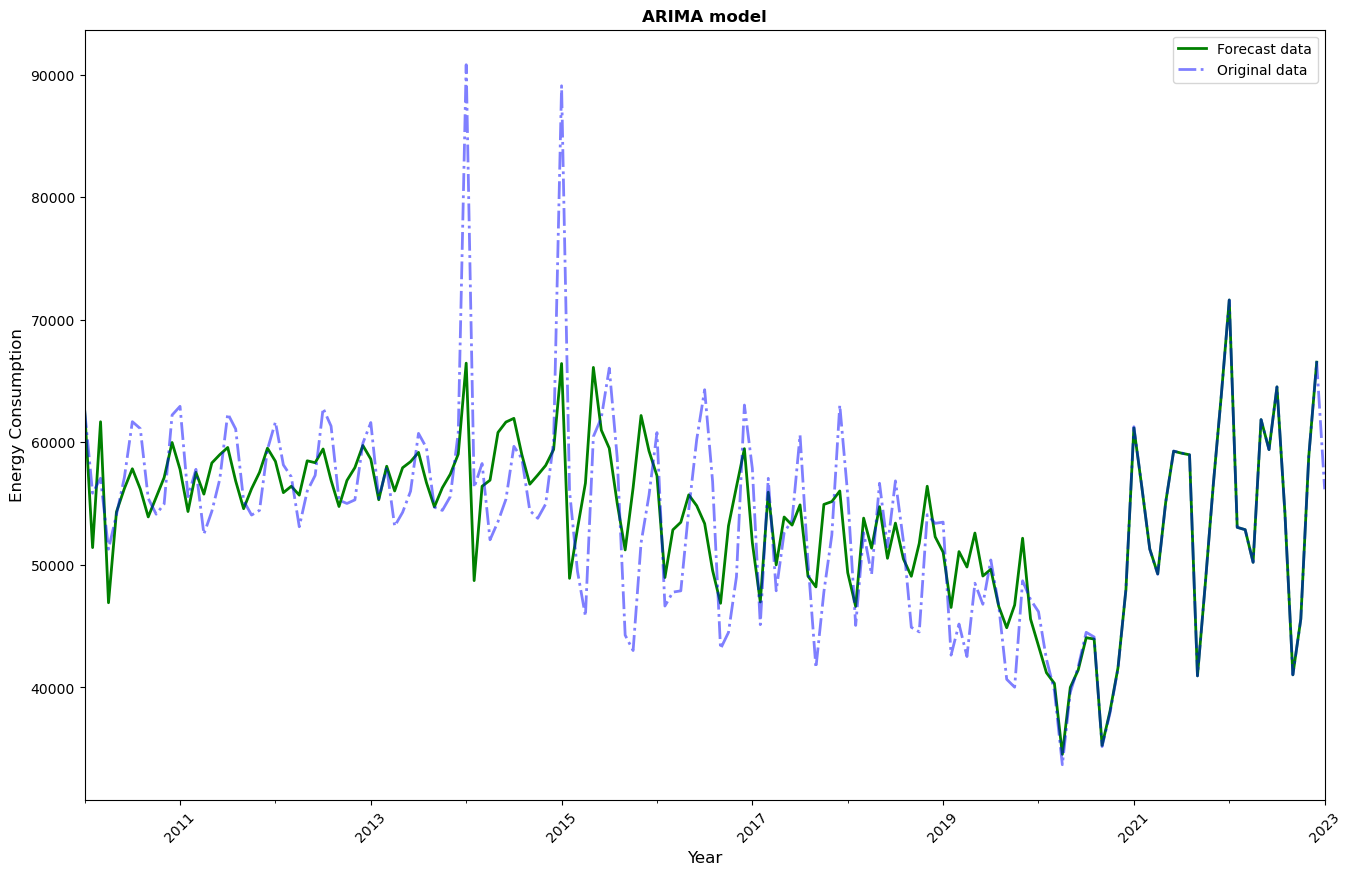

In [55]:
# 62.d Plot the original values and the forecast values to compare
plt.Figure(figsize=(12, 6))
df_series['forecast'].plot(color='green', label='Forecast data')
df_series['energy_consumption'].plot(color='blue', linestyle='-.', alpha=0.50, label='Original data')

plt.xticks(rotation=45)
plt.xlabel("Year")
plt.ylabel("Energy Consumption")
plt.legend(loc='best')
plt.title('ARIMA model', fontweight='bold')
plt.show()

In [56]:
# 63. Invert the test data to run some evaluation metrics
#test_log = test.shift(-1) + df_series['energy_consumption_log'][-len(test):]
#test_original_scale = np.exp(test_log)

# 63. Evaluating the model
from sklearn.metrics import mean_squared_error

# 63.a Calculating the MSE for the model
print(f'RMSE score for SARIMAX model: {np.sqrt(mean_squared_error(df_series['energy_consumption'][:-1], df_series['forecast'].dropna()))}')

RMSE score for SARIMAX model: 4600.171448054494


In [57]:
# 63. b Evaluate by MAPE
from sklearn.metrics import mean_absolute_percentage_error
print(f'MAPE score for SARIMAX model: {mean_absolute_percentage_error(df_series['energy_consumption'][:-1], df_series['forecast'].dropna())*100}')

MAPE score for SARIMAX model: 5.39121449490816


### Conclusions
Through this project I was able to learn how to analyze and prepare a time series before trying to predict any data. I also learned that in order to forecast a data series, this needs to be stationary, which means that the mean and variance do not change over time, if this criterion is not met, the predictions may not be reliable. I also was able to learn about the SARIMAX model to forecast a time series. This helped me to gain knowledge about this model and how to use it for future projects.